In [214]:
#Importing the data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import seaborn as sns
import itertools
import math

!pip install pyproj
!pip install adjustText
!pip install tabulate


from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from scipy.stats import gaussian_kde
from scipy import stats
from scipy.stats import linregress
from scipy.stats import shapiro, ks_2samp, levene, ttest_ind, mannwhitneyu


from pyproj import Transformer

from adjustText import adjust_text

In [215]:
# Reading the csv data files
df = pd.read_csv("AvulsionAngles.csv")
df2 = pd.read_csv("Profiles.csv")

In [216]:
# Defining apex and toe coordiantes
# Haversine distance function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # meters
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(delta_lambda/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c


# ===============================================
# Step 1: Define Apex and Toe coordinates
# ===============================================
apex_coords = {
    "Abrisham": (35.61570558, 56.2550051),
    "Canning": (69.851, -146.461),
    "Cusay": (6.69162445, -71.84111181),
    "Ili": (44.8169747, 76.2228272),
    "Karnali": (28.610688, 81.2744661),
    "Kosi": (26.53, 86.938),
    "Manas": (26.78284555, 90.95510889),
    "Niger": (14.13861504, -5.02443996),
    "Nomhon He": (36.209, 96.385),
    "Okavango": (-18.858, 22.382),
    "Rud-i-Shur Tabas": (32.69999266, 60.54639206),
    "Saskatchewan": (53.70749938, -103.22863607),
    "Shire": (-16.2056, 34.9333)
}

toe_coords = {
    "Abrisham": (35.4077960, 55.9442017),
    "Canning": (70.0776829, -145.8115939),
    "Cusay": (6.70164919, -71.1415035),
    "Ili": (46.5798760, 75.4267887),
    "Karnali": (28.272984, 81.0855275),
    "Kosi": (25.4124270, 87.2551879),
    "Manas": (26.2501896, 90.817693),
    "Niger": (15.29728494, -3.97095891),
    "Nomhon He": (36.5690979, 96.467773),
    "Okavango": (-19.2357331, 23.9332574),
    "Rud-i-Shur Tabas": (32.6369173, 60.8883672),
    "Saskatchewan": (54.036199, -102.520279),
    "Shire": (-16.5488535, 35.12352637)
}

C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\3734660344.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apex_rows['dist_to_true_apex'] = np.sqrt(
C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\3734660344.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apex_rows['dist_to_true_apex'] = np.sqrt(
C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\3734660344.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

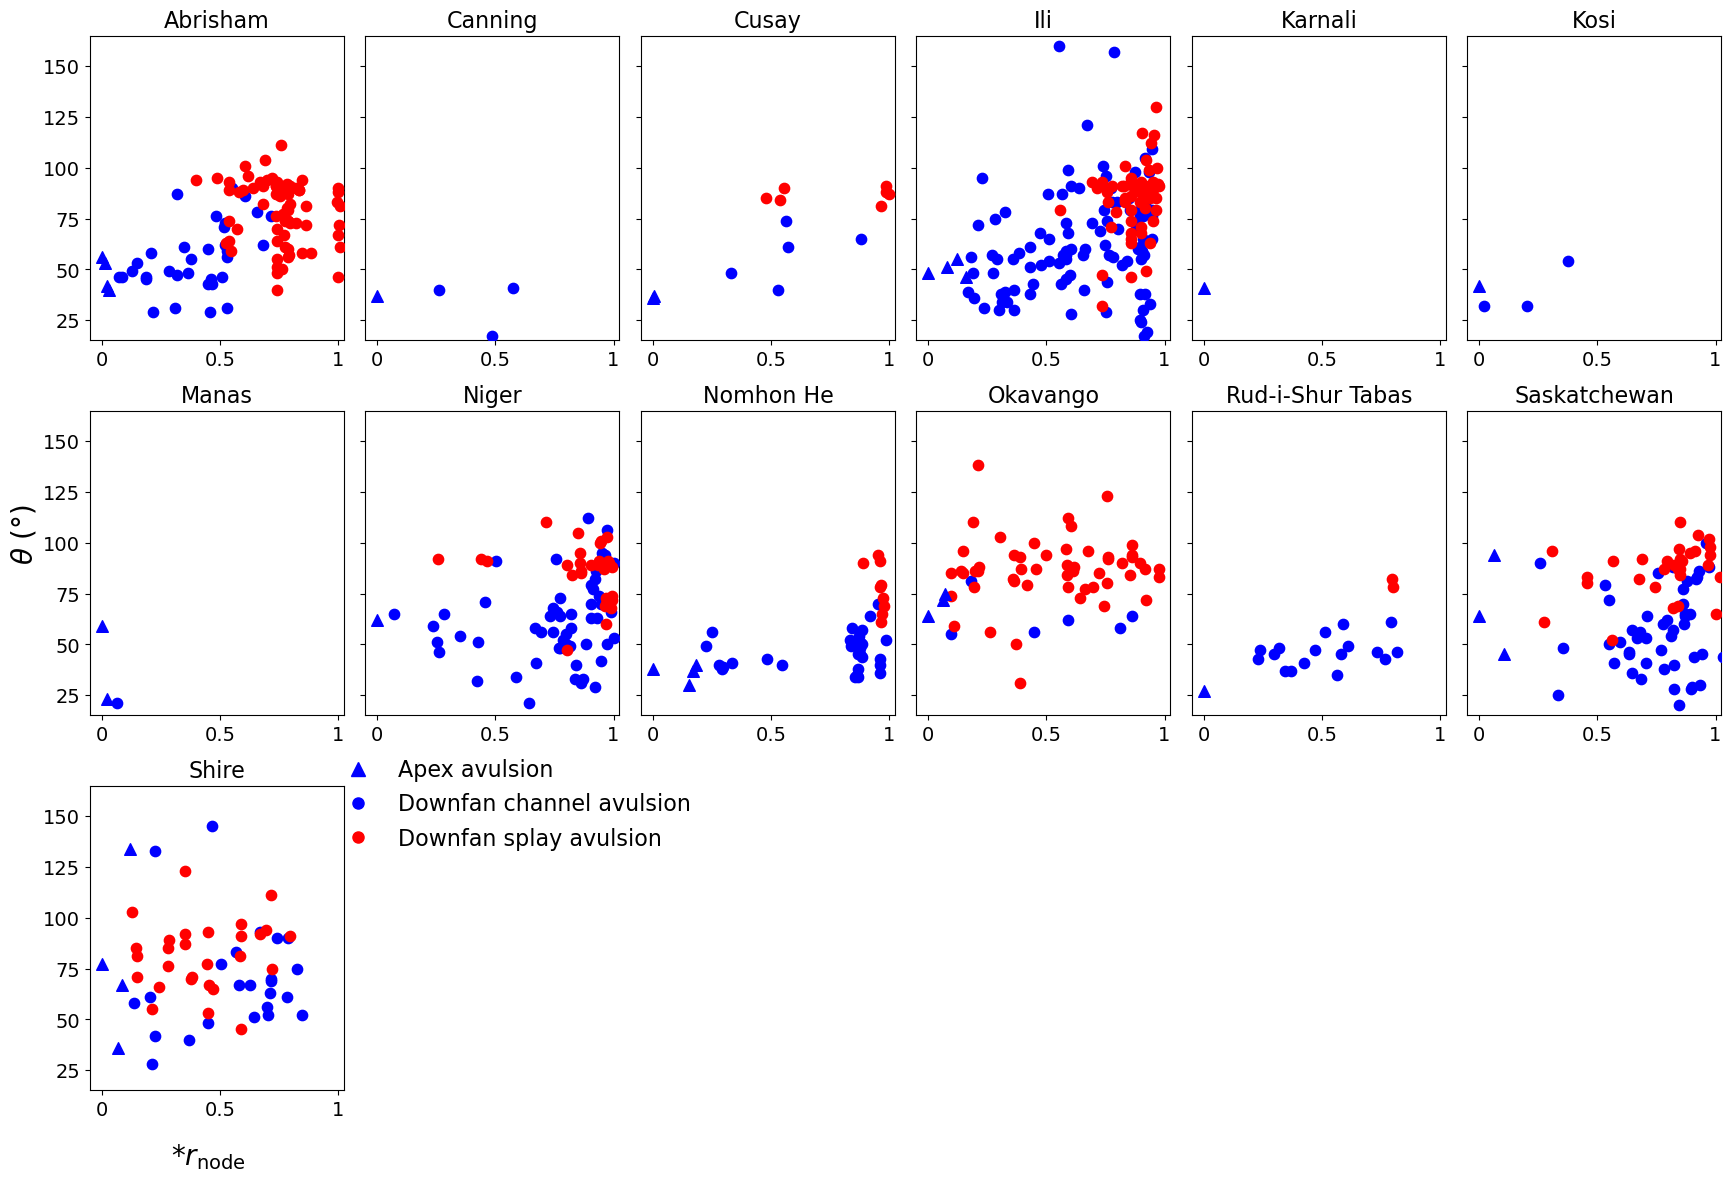

In [217]:
# Data clouds of avulsion nodes
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # radius of Earth (m)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df['Apex'] = df['Apex'].astype(str).str.strip()
df['Crevasse'] = df['Crevasse'].astype(str).str.strip()
df['Angle'] = pd.to_numeric(df['Angle'], errors='coerce')

ref_apex_index = {}

for fan in df['Fan'].unique():
    if fan not in apex_coords:
        continue

    apex_lat, apex_lon = apex_coords[fan]
    fan_rows = df[df['Fan'] == fan].copy()
    apex_rows = fan_rows[fan_rows['Apex'] == 'Yes']

    if len(apex_rows) > 0:
        apex_rows['dist_to_true_apex'] = np.sqrt(
            (apex_rows['Latitude'] - apex_lat) ** 2 +
            (apex_rows['Longitude'] - apex_lon) ** 2
        )
        ref_apex_index[fan] = apex_rows.loc[apex_rows['dist_to_true_apex'].idxmin()].name
    else:
        ref_apex_index[fan] = None

        
        
df['Distance_m'] = np.nan
df['Distance_norm'] = np.nan

for fan in df['Fan'].unique():
    if fan not in apex_coords or fan not in toe_coords:
        continue

    apex_lat, apex_lon = apex_coords[fan]
    toe_lat, toe_lon = toe_coords[fan]
    total_dist = haversine(apex_lat, apex_lon, toe_lat, toe_lon)

    fan_mask = df['Fan'] == fan
    df.loc[fan_mask, 'Distance_m'] = df.loc[fan_mask].apply(
        lambda row: haversine(apex_lat, apex_lon, row['Latitude'], row['Longitude']),
        axis=1
    )

    # Normalize
    if total_dist == 0:
        df.loc[fan_mask, 'Distance_norm'] = 0
    else:
        df.loc[fan_mask, 'Distance_norm'] = df.loc[fan_mask, 'Distance_m'] / total_dist

    if ref_apex_index[fan] is not None:
        df.loc[ref_apex_index[fan], 'Distance_norm'] = 0


        
        
fan_list = df['Fan'].unique()
n_fans = len(fan_list)
n_cols = 6
n_rows = int(np.ceil(n_fans / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=True)
axes = axes.flatten()

for i, fan in enumerate(fan_list):
    fan_data = df[df['Fan'] == fan]

    if fan_data.empty:
        axes[i].axis('off')
        continue

    # Apex points
    apex_points = fan_data[fan_data['Apex'] == 'Yes']
    axes[i].scatter(
        apex_points['Distance_norm'], apex_points['Angle'],
        c='blue', marker='^', s=70, zorder=5, label='Apex'
    )

    # Downfan points
    downfan_points = fan_data[fan_data['Apex'] == 'No']
    if not downfan_points.empty:
        crev_no = downfan_points[downfan_points['Crevasse'] == 'No']
        crev_yes = downfan_points[downfan_points['Crevasse'] == 'Yes']

        axes[i].scatter(
            crev_no['Distance_norm'], crev_no['Angle'],
            c='blue', marker='o', s=55, zorder=4, label='Avulsion'
        )
        axes[i].scatter(
            crev_yes['Distance_norm'], crev_yes['Angle'],
            c='red', marker='o', s=55, zorder=4, label='Crevasse'
        )

    axes[i].set_title(fan, fontsize=16)
    axes[i].set_xlim(-0.05, 1.025)
    axes[i].set_ylim(15, 165)
    axes[i].grid(False)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    # ✅ Set clean whole-number x-axis ticks
    axes[i].set_xticks([0, 0.5, 1])
    axes[i].set_xticklabels(['0', '0.5', '1'], fontsize=14)

    # ✅ Set y-axis tick label font size
    axes[i].tick_params(axis='y', labelsize=14)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# ===============================================
# Step 5: Global legend and labels (manual position)
# ===============================================
legend_elements = [
    Line2D([0], [0], marker='^', color='blue', linestyle='None', markersize=10, label='Apex avulsion'),
    Line2D([0], [0], marker='o', color='blue', linestyle='None', markersize=8, label='Downfan channel avulsion'),
    Line2D([0], [0], marker='o', color='red', linestyle='None', markersize=8, label='Downfan splay avulsion')
]

# Add legend manually
fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.16, 0.275),
    frameon=False,
    fontsize=16
)

# Global axis labels
fig.text(0.1, -0.025, r'$*r_{\mathrm{node}}$', ha='center', fontsize=20)
fig.text(-0.01, 0.5, r'$\theta$ (°)', va='center', rotation='vertical', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


In [218]:
# ==========================================================
# Define fan groups
# ==========================================================
group_1_fans = ["Niger", "Okavango", "Saskatchewan", "Shire", "Abrisham", "Ili"]
subgroup_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
subgroup_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

# ==========================================================
# Function to assign groups
# ==========================================================
def assign_group(fan_name):
    if fan_name in group_1_fans:
        return "Group 1"
    elif fan_name in subgroup_2a_fans:
        return "Subgroup 2a"
    elif fan_name in subgroup_2b_fans:
        return "Subgroup 2b"
    else:
        return np.nan  # or "Unassigned" if you prefer text instead of blank

# ==========================================================
# Apply group assignment
# ==========================================================
df["Group"] = df["Fan"].apply(assign_group)


In [219]:
# ============================================================
# Compute % downfan distance of first splay (Crevasse == 'Yes')
# ============================================================

first_splay_distances = {}

for fan in df['Fan'].unique():
    # Filter only this fan's data
    fan_data = df[df['Fan'] == fan]
    # Select only splay (Crevasse == 'Yes')
    splay_nodes = fan_data[fan_data['Crevasse'] == 'Yes']

    if splay_nodes.empty:
        first_splay_distances[fan] = None
        continue

    # Find the node closest to apex (minimum normalized distance)
    first_splay = splay_nodes.loc[splay_nodes['Distance_norm'].idxmin()]
    dist_percent = first_splay['Distance_norm'] * 100

    first_splay_distances[fan] = dist_percent

# Display results nicely
print("=== First Splay Distance from Apex (% of fan length) ===")
for fan, pct in first_splay_distances.items():
    if pct is None or np.isnan(pct):
        print(f"{fan}: No splay avulsions mapped")
    else:
        print(f"{fan}: First splay occurs {pct:.1f}% downfan from the apex")


=== First Splay Distance from Apex (% of fan length) ===
Abrisham: First splay occurs 39.8% downfan from the apex
Canning: No splay avulsions mapped
Cusay: First splay occurs 48.0% downfan from the apex
Ili: First splay occurs 55.7% downfan from the apex
Karnali: No splay avulsions mapped
Kosi: No splay avulsions mapped
Manas: No splay avulsions mapped
Niger: First splay occurs 25.9% downfan from the apex
Nomhon He: First splay occurs 88.8% downfan from the apex
Okavango: First splay occurs 7.1% downfan from the apex
Rud-i-Shur Tabas: First splay occurs 79.6% downfan from the apex
Saskatchewan: First splay occurs 27.5% downfan from the apex
Shire: First splay occurs 8.7% downfan from the apex


C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\247457850.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\247457850.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_all = df_plot_all.groupby("Group")["Angle"]


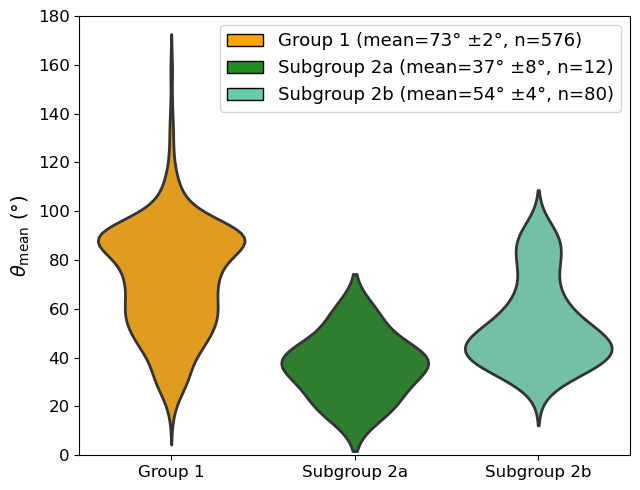

In [220]:
# -----------------------------
# Violin Plot: All Angles by Group
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats

x_label = ""
y_label = r"$\theta_{\mathrm{mean}}\ (°)$"
title_all = ""

# Updated groups — match your DataFrame exactly
order = ["Group 1", "Subgroup 2a", "Subgroup 2b"]

# Ensure Group column exists and is properly categorized
df_plot_all = df[df["Group"].isin(order)].copy()
df_plot_all["Group"] = pd.Categorical(df_plot_all["Group"], categories=order, ordered=True)

# Define consistent color palette for the three groups
colors = {
    "Group 1": "#FFA500",      # orange
    "Subgroup 2a": "#228B22",  # forest green
    "Subgroup 2b": "#66CDAA"   # medium aquamarine
}

# Adjustable font sizes
title_font = 16
label_font = 14
tick_font = 12
legend_font = 13

# Create figure
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    x="Group",
    y="Angle",
    data=df_plot_all,
    order=order,
    palette=colors,
    linewidth=2,
    inner=None
)

# Compute mean, count, and 95% CI for each group
grouped_all = df_plot_all.groupby("Group")["Angle"]
means_all = grouped_all.mean()
counts_all = grouped_all.count()

ci_dict_all = {}
for g in order:
    xdata = df_plot_all.loc[df_plot_all["Group"] == g, "Angle"]
    if len(xdata) > 1:
        ci_low, ci_high = stats.t.interval(
            0.95, len(xdata) - 1,
            loc=means_all[g], scale=stats.sem(xdata)
        )
        ci_dict_all[g] = (ci_low, ci_high)
    elif len(xdata) == 1:
        ci_dict_all[g] = (means_all[g], means_all[g])
    else:
        ci_dict_all[g] = (np.nan, np.nan)

# Build legend with mean ± CI and counts
legend_elements = []
for g in order:
    if g in means_all.index:
        ci_low, ci_high = ci_dict_all[g]
        mean_val = round(means_all[g])
        ci_half = round(ci_high - means_all[g]) if not np.isnan(ci_high) else 0
        label = f"{g} (mean={mean_val}° ±{ci_half}°, n={int(counts_all[g])})"
        legend_elements.append(Patch(facecolor=colors[g], edgecolor="k", label=label))

# Legend + styling
ax.legend(handles=legend_elements, fontsize=legend_font, loc="upper right", frameon=True)
ax.set_title(title_all, fontsize=title_font)
ax.set_xlabel(x_label, fontsize=label_font)
ax.set_ylabel(y_label, fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.grid(False)

ax.set_ylim(0, 180)
plt.tight_layout()
plt.show()


In [221]:
# -----------------------------
# CONFIG
# -----------------------------
alpha = 0.05
group_a = "Group 1"
group_b = "Subgroup 2b"   # ✅ updated to match your dataframe naming
col_group = "Group"
col_angle = "Angle"

# -----------------------------
# Helper functions
# -----------------------------
def fmt_p(p):
    if p < 1e-12:
        return "p = 0 (< 0.05)"
    elif p < alpha:
        return "p < 0.05"
    else:
        return "p ≥ 0.05"


def normality_tests(name, x):
    x = np.asarray(pd.to_numeric(pd.Series(x), errors="coerce").dropna())
    n = x.size
    out = {"name": name, "n": n, "shapiro_p": np.nan, "ks_p": np.nan, "is_normal": False}
    if n < 3:
        print(f"[{name}] Not enough data for normality tests (n={n}).")
        return out

    # Shapiro–Wilk test
    try:
        W, p_sh = stats.shapiro(x)
    except Exception:
        p_sh = np.nan

    # Kolmogorov–Smirnov test against normal distribution
    m, s = np.mean(x), np.std(x, ddof=1)
    if s > 0 and n >= 3:
        z = (x - m) / s
        D, p_ks = stats.kstest(z, 'norm')
    else:
        p_ks = np.nan

    is_norm = (not np.isnan(p_sh) and p_sh >= alpha) and (not np.isnan(p_ks) and p_ks >= alpha)

    print(f"[{name}] Normality — Shapiro: {fmt_p(p_sh)}; KS: {fmt_p(p_ks)} "
          f"→ {'consistent with normality' if is_norm else 'NOT normal (reject at 0.05)'}")

    out.update({"shapiro_p": p_sh, "ks_p": p_ks, "is_normal": is_norm})
    return out


def variance_test(xa, xb, a_is_norm, b_is_norm):
    xa = np.asarray(pd.to_numeric(pd.Series(xa), errors="coerce").dropna())
    xb = np.asarray(pd.to_numeric(pd.Series(xb), errors="coerce").dropna())

    if a_is_norm and b_is_norm:
        stat, p = stats.bartlett(xa, xb)
        test_name = "Bartlett (equal variances, normal)"
    else:
        stat, p = stats.levene(xa, xb, center='median')
        test_name = "Levene (equal variances, robust)"

    same_var = p >= alpha
    print(f"[Variance] {test_name}: {fmt_p(p)} "
          f"→ {'variances similar (fail to reject H0)' if same_var else 'variances differ (reject H0)'}")
    return same_var, p, test_name


def mean_test(xa, xb, both_normal, equal_var):
    xa = np.asarray(pd.to_numeric(pd.Series(xa), errors="coerce").dropna())
    xb = np.asarray(pd.to_numeric(pd.Series(xb), errors="coerce").dropna())

    if both_normal and equal_var:
        stat, p = stats.ttest_ind(xa, xb, equal_var=True)
        test_name = "Student t-test (equal variances)"
    elif both_normal and not equal_var:
        stat, p = stats.ttest_ind(xa, xb, equal_var=False)
        test_name = "Welch t-test (unequal variances)"
    else:
        stat, p = stats.mannwhitneyu(xa, xb, alternative='two-sided')
        test_name = "Mann–Whitney U (nonparametric)"

    print(f"[Means] {test_name}: {fmt_p(p)} "
          f"→ {'means differ (reject H0)' if p < alpha else 'no evidence of mean difference (fail to reject H0)'}")
    return p, test_name


# -----------------------------
# Extract data
# -----------------------------
g1 = df.loc[df[col_group] == group_a, col_angle].dropna().values
g2b = df.loc[df[col_group] == group_b, col_angle].dropna().values

print(f"{group_a}: n={len(g1)}, mean={np.nanmean(g1):.2f}°, SD={np.nanstd(g1, ddof=1):.2f}°")
print(f"{group_b}: n={len(g2b)}, mean={np.nanmean(g2b):.2f}°, SD={np.nanstd(g2b, ddof=1):.2f}°")

# -----------------------------
# Run tests
# -----------------------------
res_a = normality_tests(group_a, g1)
res_b = normality_tests(group_b, g2b)
both_normal = res_a["is_normal"] and res_b["is_normal"]

equal_var, p_var, var_test_name = variance_test(g1, g2b, res_a["is_normal"], res_b["is_normal"])
p_mean, mean_test_name = mean_test(g1, g2b, both_normal, equal_var)


Group 1: n=576, mean=72.60°, SD=22.45°
Subgroup 2b: n=80, mean=54.05°, SD=17.65°
[Group 1] Normality — Shapiro: p < 0.05; KS: p < 0.05 → NOT normal (reject at 0.05)
[Subgroup 2b] Normality — Shapiro: p < 0.05; KS: p < 0.05 → NOT normal (reject at 0.05)
[Variance] Levene (equal variances, robust): p < 0.05 → variances differ (reject H0)
[Means] Mann–Whitney U (nonparametric): p < 0.05 → means differ (reject H0)


C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\1515106031.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\1515106031.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_apex = df_plot_apex.groupby("Group")["Angle"]


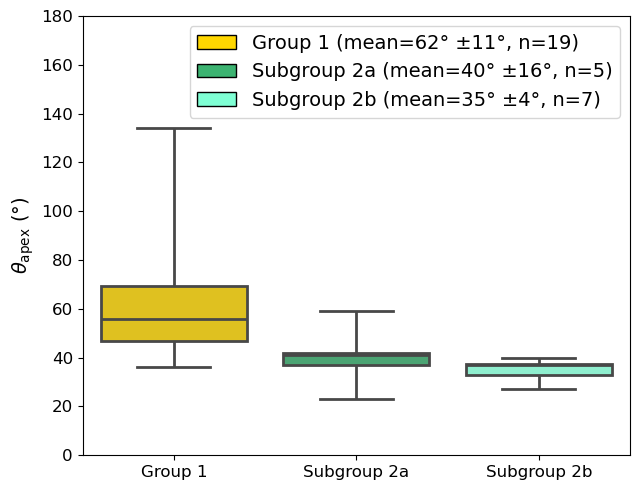

In [222]:
# -----------------------------
# Box Plot: Apex Angles (Group 1, Subgroup 2a, Subgroup 2b)
# -----------------------------
x_label = ""  # match previous style
y_label = r"$\theta_{\mathrm{apex}}$ (°)"
title_apex = ""  # no title for consistency
order = ["Group 1", "Subgroup 2a", "Subgroup 2b"]

# --- Ensure groups are assigned dynamically ---
def assign_group(fan):
    if fan in group_1_fans:
        return "Group 1"
    elif fan in subgroup_2a_fans:
        return "Subgroup 2a"
    elif fan in subgroup_2b_fans:
        return "Subgroup 2b"
    else:
        return np.nan  # keeps it clean if no match

# Apply consistent grouping logic
df["Group"] = df["Fan"].apply(assign_group)

# --- Filter to apex avulsion angles only ---
df_plot_apex = df[(df["Group"].isin(order)) & (df["Apex"] == "Yes")].copy()
df_plot_apex["Group"] = pd.Categorical(df_plot_apex["Group"], categories=order, ordered=True)

# --- Color palette (consistent with previous plots) ---
colors = {
    "Group 1": "gold",       # orange
    "Subgroup 2a": "mediumseagreen",   # forest green
    "Subgroup 2b": "aquamarine"    # medium aquamarine
}

# --- Adjustable font sizes (consistent with violin plot) ---
title_font = 16
label_font = 14
tick_font = 12
legend_font = 14

plt.figure(figsize=(6.5, 5))
ax = sns.boxplot(
    x="Group",
    y="Angle",
    data=df_plot_apex,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=2,
    whis=[0, 100]
)

# --- Compute mean, count, and 95% CI ---
grouped_apex = df_plot_apex.groupby("Group")["Angle"]
means_apex = grouped_apex.mean()
counts_apex = grouped_apex.count()

ci_dict_apex = {}
for g in order:
    xdata = df_plot_apex[df_plot_apex["Group"] == g]["Angle"]
    if len(xdata) > 1:
        ci_low, ci_high = stats.t.interval(
            0.95, len(xdata) - 1,
            loc=means_apex[g], scale=stats.sem(xdata)
        )
        ci_dict_apex[g] = (ci_low, ci_high)
    elif len(xdata) == 1:
        ci_dict_apex[g] = (means_apex[g], means_apex[g])
    else:
        ci_dict_apex[g] = (np.nan, np.nan)

# --- Legend with degree symbol and integer rounding ---
legend_elements = []
for g in order:
    if g in means_apex:
        ci_low, ci_high = ci_dict_apex[g]
        mean_val = round(means_apex[g])
        ci_half = round(ci_high - means_apex[g]) if not np.isnan(ci_high) else 0
        label = f"{g} (mean={mean_val}° ±{ci_half}°, n={int(counts_apex[g])})"
        legend_elements.append(Patch(facecolor=colors[g], edgecolor="k", label=label))

ax.legend(handles=legend_elements, fontsize=legend_font, loc="upper right")
ax.set_title(title_apex, fontsize=title_font)
ax.set_xlabel(x_label, fontsize=label_font)
ax.set_ylabel(y_label, fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.grid(False)

ax.set_ylim(0, 180)
plt.tight_layout()
plt.show()


C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\1832355068.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\1832355068.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, fontsize=tick_font)


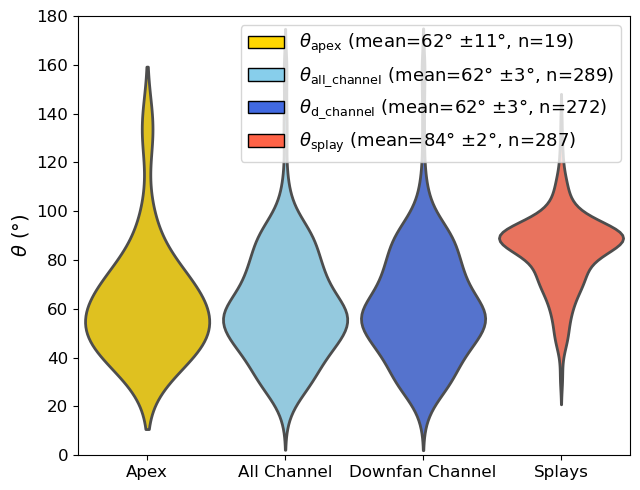

In [223]:
# =============================================
# Group 1 Violin Plot – Original Style (Legend Inside)
# =============================================

# -----------------------------
# Labels and Colors
# -----------------------------
y_label = r"$\theta$ (°)"
title_group1 = ""
order_conditions = ["Apex", "All Channel", "Downfan", "Splays"]

# Colors
default_colors = {
    "All Channel": "skyblue",
    "Downfan": "royalblue",
    "Splays": "tomato"
}
apex_color = "gold"
palette = {
    "Apex": apex_color,
    "All Channel": default_colors["All Channel"],
    "Downfan": default_colors["Downfan"],
    "Splays": default_colors["Splays"],
}

# Fonts
title_font = 16
label_font = 14
tick_font = 12
legend_font = 13

# -----------------------------
# Prepare Data
# -----------------------------
df_g1 = df[df["Group"] == "Group 1"].copy()

# --- Explicit subsets ---
apex_df = df_g1[df_g1["Apex"] == "Yes"].copy()
apex_df["Condition"] = "Apex"

allchan_df = df_g1[df_g1["Crevasse"] == "No"].copy()
allchan_df["Condition"] = "All Channel"

downfan_df = df_g1[(df_g1["Apex"] == "No") & (df_g1["Crevasse"] == "No")].copy()
downfan_df["Condition"] = "Downfan"

splay_df = df_g1[df_g1["Crevasse"] == "Yes"].copy()
splay_df["Condition"] = "Splays"

# Combine all subsets
df_g1_combined = pd.concat([apex_df, allchan_df, downfan_df, splay_df], ignore_index=True)
df_g1_combined["Condition"] = pd.Categorical(
    df_g1_combined["Condition"], categories=order_conditions, ordered=True
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    data=df_g1_combined,
    x="Condition",
    y="Angle",
    palette=palette,
    linewidth=2,
    inner=None,
    cut=2,
    width=0.9
)

# -----------------------------
# Legend: θ with subscripts + Mean ± 95% CI
# -----------------------------
label_map = {
    "Apex":        r"$\theta_{\mathrm{apex}}$",
    "All Channel": r"$\theta_{\mathrm{all\_channel}}$",
    "Downfan":     r"$\theta_{\mathrm{d\_channel}}$",
    "Splays":      r"$\theta_{\mathrm{splay}}$",
}

legend_elements = []
for cond in order_conditions:
    cond_data = df_g1_combined[df_g1_combined["Condition"] == cond]["Angle"]
    if not cond_data.empty:
        n = len(cond_data)
        mean = np.mean(cond_data)
        sem = stats.sem(cond_data)
        ci = sem * stats.t.ppf((1 + 0.95) / 2., n - 1) if n > 1 else 0
        label = f"{label_map[cond]} (mean={round(mean)}° ±{round(ci)}°, n={n})"
        legend_elements.append(Patch(facecolor=palette[cond], edgecolor="k", label=label))

# -----------------------------
# Formatting
# -----------------------------
ax.legend(handles=legend_elements, fontsize=legend_font, loc="upper right", frameon=True)
ax.set_title(title_group1, fontsize=title_font)
ax.set_xlabel("")
ax.set_ylabel(y_label, fontsize=label_font)

# Custom x-axis tick labels
custom_labels = [
    "Apex",
    "All Channel",
    "Downfan Channel",
    "Splays"
]
ax.set_xticklabels(custom_labels, fontsize=tick_font)

ax.tick_params(axis="both", labelsize=tick_font)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()


C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\2992892057.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


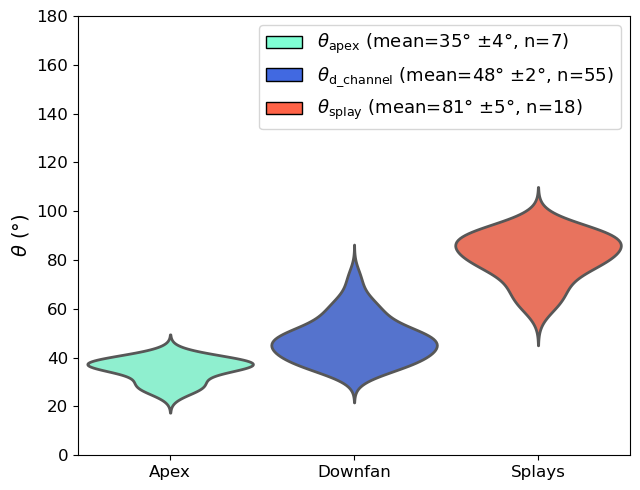

In [224]:
# =============================================
# Subgroup 2b Violin Plot – Original Style (Legend Inside)
# =============================================

# -----------------------------
# Plot Settings
# -----------------------------
x_label = ""
y_label = r"$\theta$ (°)"
title_group2b = ""
order_conditions = ["Apex", "Downfan", "Splays"]

# Colors
default_colors = {"Downfan": "royalblue", "Splays": "tomato"}
apex_color = "aquamarine"  # ✅ Subgroup 2b color
palette = {
    "Apex": apex_color,
    "Downfan": default_colors["Downfan"],
    "Splays": default_colors["Splays"],
}

# Fonts
title_font = 16
label_font = 14
tick_font = 12
legend_font = 13

# -----------------------------
# Prepare Data
# -----------------------------
df_g2b = df[df["Group"] == "Subgroup 2b"].copy()
df_g2b["Condition"] = np.select(
    [
        df_g2b["Apex"] == "Yes",
        df_g2b["Crevasse"] == "No",
        df_g2b["Crevasse"] == "Yes",
    ],
    ["Apex", "Downfan", "Splays"],
    default=np.nan
)
df_g2b = df_g2b[df_g2b["Condition"].isin(order_conditions)]
df_g2b["Condition"] = pd.Categorical(
    df_g2b["Condition"], categories=order_conditions, ordered=True
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    data=df_g2b,
    x="Condition",
    y="Angle",
    palette=palette,
    linewidth=2,
    inner=None,
    cut=3,
    width=0.9
)

# -----------------------------
# Legend: θ with subscripts (no parentheses) + Mean ± 95% CI
# -----------------------------
label_map = {
    "Apex":     r"$\theta_{\mathrm{apex}}$",
    "Downfan": r"$\theta_{\mathrm{d\_channel}}$",
    "Splays":   r"$\theta_{\mathrm{splay}}$",
}

legend_elements = []
for cond in order_conditions:
    cond_data = df_g2b[df_g2b["Condition"] == cond]["Angle"]
    if not cond_data.empty:
        n = len(cond_data)
        mean = np.mean(cond_data)
        sem = stats.sem(cond_data)
        ci = sem * stats.t.ppf((1 + 0.95) / 2., n - 1) if n > 1 else 0
        label = f"{label_map[cond]} (mean={round(mean)}° ±{round(ci)}°, n={n})"
        legend_elements.append(Patch(facecolor=palette[cond], edgecolor="k", label=label))

# -----------------------------
# Formatting
# -----------------------------
ax.legend(handles=legend_elements, fontsize=legend_font, loc="upper right", frameon=True)
ax.set_title(title_group2b, fontsize=title_font)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label, fontsize=label_font)   # ← uses θ (°)
ax.tick_params(axis="both", labelsize=tick_font)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()


C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\2225697254.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\2225697254.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, fontsize=12)  # adjust text here as needed


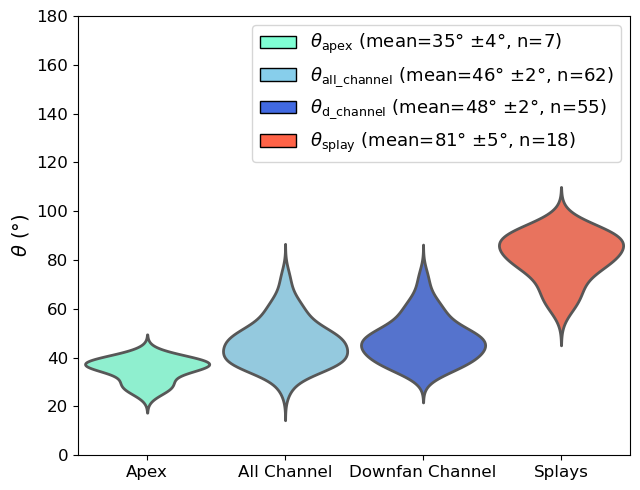

In [225]:
# =============================================
# Subgroup 2b Violin Plot – Original Style (Legend Inside, with All Channel)
# =============================================

# -----------------------------
# Plot Settings
# -----------------------------
x_label = ""
y_label = r"$\theta$ (°)"
title_group2b = ""
order_conditions = ["Apex", "All Channel", "Downfan", "Splays"]

# Colors
default_colors = {
    "All Channel": "skyblue",
    "Downfan": "royalblue",
    "Splays": "tomato",
}
apex_color = "aquamarine"  # ✅ Subgroup 2b color
palette = {
    "Apex": apex_color,
    "All Channel": default_colors["All Channel"],
    "Downfan": default_colors["Downfan"],
    "Splays": default_colors["Splays"],
}

# Fonts
title_font = 16
label_font = 14
tick_font = 12
legend_font = 13

# -----------------------------
# Prepare Data
# -----------------------------
df_g2b = df[df["Group"] == "Subgroup 2b"].copy()

# --- Explicit subsets ---
apex_df = df_g2b[df_g2b["Apex"] == "Yes"].copy()
apex_df["Condition"] = "Apex"

allchan_df = df_g2b[df_g2b["Crevasse"] == "No"].copy()
allchan_df["Condition"] = "All Channel"

downfan_df = df_g2b[(df_g2b["Apex"] == "No") & (df_g2b["Crevasse"] == "No")].copy()
downfan_df["Condition"] = "Downfan"

splay_df = df_g2b[df_g2b["Crevasse"] == "Yes"].copy()
splay_df["Condition"] = "Splays"

# Combine all subsets
df_g2b_combined = pd.concat(
    [apex_df, allchan_df, downfan_df, splay_df], ignore_index=True
)
df_g2b_combined["Condition"] = pd.Categorical(
    df_g2b_combined["Condition"], categories=order_conditions, ordered=True
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    data=df_g2b_combined,
    x="Condition",
    y="Angle",
    palette=palette,
    linewidth=2,
    inner=None,
    cut=3,
    width=0.9,
)

# -----------------------------
# Legend: θ with subscripts + Mean ± 95% CI
# -----------------------------
label_map = {
    "Apex":        r"$\theta_{\mathrm{apex}}$",
    "All Channel": r"$\theta_{\mathrm{all\_channel}}$",
    "Downfan":     r"$\theta_{\mathrm{d\_channel}}$",
    "Splays":      r"$\theta_{\mathrm{splay}}$",
}

legend_elements = []
for cond in order_conditions:
    cond_data = df_g2b_combined[df_g2b_combined["Condition"] == cond]["Angle"]
    if not cond_data.empty:
        n = len(cond_data)
        mean = np.mean(cond_data)
        sem = stats.sem(cond_data)
        ci = sem * stats.t.ppf((1 + 0.95) / 2.0, n - 1) if n > 1 else 0
        label = f"{label_map[cond]} (mean={round(mean)}° ±{round(ci)}°, n={n})"
        legend_elements.append(
            Patch(facecolor=palette[cond], edgecolor="k", label=label)
        )

# -----------------------------
# Formatting
# -----------------------------
ax.legend(handles=legend_elements, fontsize=legend_font, loc="upper right", frameon=True)
ax.set_title(title_group2b, fontsize=title_font)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label, fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.set_ylim(0, 180)
ax.grid(False)

# -----------------------------
# Custom X-axis labels (no rotation)
# -----------------------------
custom_labels = [
    "Apex",
    "All Channel",
    "Downfan Channel",
    "Splays"
]
ax.set_xticklabels(custom_labels, fontsize=12)  # adjust text here as needed

plt.tight_layout()
plt.show()




In [226]:
# =============================================
# Downfan Avulsion Statistical Comparison
# (Group 1 vs Subgroup 2b)
# =============================================

import numpy as np
import pandas as pd
from scipy import stats

# ---- Settings ----
alpha = 0.05
group_a, group_b = "Group 1", "Subgroup 2b"  # ✅ updated naming
col_group = "Group"
col_angle = "Angle"

# ---- Ensure groups are correctly assigned ----
# Assumes you have these lists defined:
# group_1_fans = [...]
# subgroup_2a_fans = [...]
# subgroup_2b_fans = [...]

def assign_group(fan):
    if fan in group_1_fans:
        return "Group 1"
    elif fan in subgroup_2a_fans:
        return "Subgroup 2a"
    elif fan in subgroup_2b_fans:
        return "Subgroup 2b"
    else:
        return np.nan  # cleaner than "Other"

df["Group"] = df["Fan"].apply(assign_group)

# ---- Helper functions ----
def fmt_p(p):
    if p is None or np.isnan(p):
        return "p = NA"
    if p < 1e-12:
        return "p = 0 (< 0.05)"
    return "p < 0.05" if p < alpha else "p ≥ 0.05"

def normality_tests(name, x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().values
    n = x.size
    if n < 3:
        print(f"[{name}] Normality: not enough data (n={n})")
        return False, np.nan, np.nan
    # Shapiro–Wilk
    try:
        _, p_sh = stats.shapiro(x)
    except Exception:
        p_sh = np.nan
    # KS vs fitted normal
    m, s = np.mean(x), np.std(x, ddof=1)
    if s > 0:
        z = (x - m) / s
        _, p_ks = stats.kstest(z, "norm")
    else:
        p_ks = np.nan
    is_norm = (not np.isnan(p_sh) and p_sh >= alpha) and (not np.isnan(p_ks) and p_ks >= alpha)
    print(f"[{name}] Normality — Shapiro: {fmt_p(p_sh)}; KS: {fmt_p(p_ks)} → "
          f"{'consistent with normality' if is_norm else 'NOT normal (reject at 0.05)'}")
    return is_norm, p_sh, p_ks

def variance_test(xa, xb, a_norm, b_norm):
    if len(xa) < 2 or len(xb) < 2:
        print("[Variance] Skipped (insufficient n). Using Welch/MWU path.")
        return False  # force robust path
    if a_norm and b_norm:
        _, p = stats.bartlett(xa, xb)
        name = "Bartlett (equal variances, normal)"
    else:
        _, p = stats.levene(xa, xb, center="median")
        name = "Levene (equal variances, robust)"
    print(f"[Variance] {name}: {fmt_p(p)} → "
          f"{'variances similar (fail to reject H0)' if p >= alpha else 'variances differ (reject H0)'}")
    return p >= alpha

def mean_test(xa, xb, both_normal, equal_var):
    if len(xa) == 0 or len(xb) == 0:
        print("[Means] Skipped (no data in one group).")
        return
    if both_normal and equal_var:
        _, p = stats.ttest_ind(xa, xb, equal_var=True)
        name = "Student t-test (equal variances)"
    elif both_normal and not equal_var:
        _, p = stats.ttest_ind(xa, xb, equal_var=False)
        name = "Welch t-test (unequal variances)"
    else:
        _, p = stats.mannwhitneyu(xa, xb, alternative="two-sided")
        name = "Mann–Whitney U (nonparametric)"
    print(f"[Means] {name}: {fmt_p(p)} → "
          f"{'means differ (reject H0)' if p < alpha else 'no evidence of a mean difference (fail to reject H0)'}")

# ---- Filter: downfan channel avulsions only ----
# (Crevasse == "No") & (Apex == "No")
mask = (
    df[col_group].isin([group_a, group_b]) &
    df["Crevasse"].eq("No") &
    df["Apex"].eq("No")
)
sub = df.loc[mask, [col_group, col_angle]].dropna()

g1  = sub.loc[sub[col_group] == group_a, col_angle].astype(float).values
g2b = sub.loc[sub[col_group] == group_b, col_angle].astype(float).values

# ---- Descriptive stats ----
print(f"{group_a} downfan avulsions: n={len(g1)}, mean={np.nanmean(g1):.2f}°, SD={np.nanstd(g1, ddof=1):.2f}°")
print(f"{group_b} downfan avulsions: n={len(g2b)}, mean={np.nanmean(g2b):.2f}°, SD={np.nanstd(g2b, ddof=1):.2f}°")

# ---- Run tests ----
a_norm, _, _ = normality_tests(f"{group_a} (downfan)", g1)
b_norm, _, _ = normality_tests(f"{group_b} (downfan)", g2b)
both_normal = a_norm and b_norm
equal_var = variance_test(g1, g2b, a_norm, b_norm)
mean_test(g1, g2b, both_normal, equal_var)


Group 1 downfan avulsions: n=272, mean=61.78°, SD=22.88°
Subgroup 2b downfan avulsions: n=55, mean=47.51°, SD=9.17°
[Group 1 (downfan)] Normality — Shapiro: p < 0.05; KS: p ≥ 0.05 → NOT normal (reject at 0.05)
[Subgroup 2b (downfan)] Normality — Shapiro: p < 0.05; KS: p ≥ 0.05 → NOT normal (reject at 0.05)
[Variance] Levene (equal variances, robust): p < 0.05 → variances differ (reject H0)
[Means] Mann–Whitney U (nonparametric): p < 0.05 → means differ (reject H0)


In [227]:
def slope_deg_from_dzdx(dz_m, dx_km):
    """Convert rise/run to degrees (elev in m, distance in km)."""
    if dx_km <= 0 or np.isnan(dz_m):
        return np.nan
    return np.degrees(np.arctan(dz_m / (dx_km * 1000.0)))  # m/m → degrees

def bulk_segment_slope_deg(dist_km, elev_m):
    """Bulk slope from first→last point in degrees, preserving sign via |dz|."""
    if len(dist_km) < 2:
        return np.nan
    dz = (elev_m.iloc[0] - elev_m.iloc[-1])  # drop from start to end (m)
    dx = (dist_km.iloc[-1] - dist_km.iloc[0])  # km
    return slope_deg_from_dzdx(np.abs(dz), dx)

# ---------------------------------------------------
# Compute drainage (0→apex) and fan (apex→end) slopes
# ---------------------------------------------------
gradient_table = []

for fan_name in df2["Fan"].unique():
    sub = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .reset_index(drop=True)
        .copy()
    )

    # Ensure strictly increasing distance (drop exact duplicates if any)
    sub = sub.loc[~sub["Distance"].duplicated()].reset_index(drop=True)

    # Find apex row (first match)
    apex_idx_list = sub.index[sub["Apex"] == "Apex"].tolist()
    if not apex_idx_list:
        print(f"⚠️ No Apex row for fan: {fan_name}")
        continue
    apex_idx = apex_idx_list[0]

    # Drainage section: 0 km → apex (inclusive)
    dr = sub.iloc[:apex_idx + 1]
    # Fan section: apex → end (inclusive)
    fn = sub.iloc[apex_idx:]

    # Bulk slopes (Δz/Δx method)
    drainage_deg = bulk_segment_slope_deg(dr["Distance"], dr["River Elevation"])
    fan_deg      = bulk_segment_slope_deg(fn["Distance"], fn["River Elevation"])

    # Store
    gradient_table.append({
        "Fan": fan_name,
        "Drainage Gradient (°)": np.round(drainage_deg, 6),
        "Fan Gradient (°)": np.round(fan_deg, 6),
        "Gradient Ratio (Drainage/Fan)": np.round(
            drainage_deg / fan_deg, 6
        ) if pd.notna(drainage_deg) and pd.notna(fan_deg) and fan_deg != 0 else np.nan,
    })

gradient_df = pd.DataFrame(gradient_table)
print(gradient_df)


                 Fan  Drainage Gradient (°)  Fan Gradient (°)  \
0           Abrisham                   0.06              0.03   
1            Canning                   0.18              0.16   
2              Cusay                   3.10              0.16   
3                Ili                   0.02              0.01   
4            Karnali                   0.09              0.06   
5               Kosi                   0.35              0.02   
6              Manas                   0.26              0.05   
7              Niger                   0.00              0.00   
8          Nomhon He                   0.72              0.51   
9           Okavango                   0.01              0.01   
10  Rud-i-Shur Tabas                   0.58              0.43   
11      Saskatchewan                   0.01              0.01   
12             Shire                   0.02              0.02   

    Gradient Ratio (Drainage/Fan)  
0                            1.99  
1                

✅ Using existing gradient_df
✅ Fan Gradient (°) merged successfully into df
✅ Group assignments applied: ['Group 1' 'Subgroup 2a' 'Subgroup 2b']


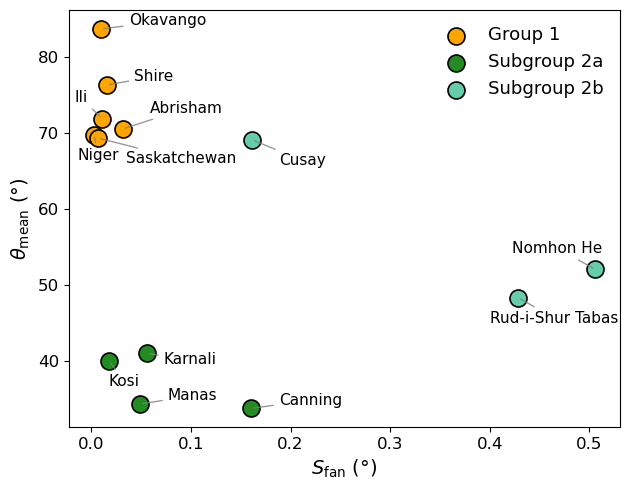

In [228]:
# ===============================================
# 1. Compute fan gradients from df2 (only if missing)
# ===============================================
if "gradient_df" not in globals() or "Fan Gradient (°)" not in globals().get("gradient_df", pd.DataFrame()).columns:
    print("⚙️ Recomputing fan gradients from df2...")
    df2["Distance_m"] = df2["Distance"] * 1000
    gradient_table = []

    for fan_name in df2["Fan"].unique():
        df_fan = df2[df2["Fan"] == fan_name].sort_values("Distance_m").copy()

        # Find Apex index
        apex_idx = df_fan[df_fan["Apex"] == "Apex"].index
        if len(apex_idx) == 0:
            print(f"⚠️ Warning: no Apex found for fan {fan_name}")
            continue
        apex_idx = apex_idx[0]

        # Drainage section (start → apex)
        drainage_dist = df_fan.loc[:apex_idx, "Distance_m"].values
        drainage_elev = df_fan.loc[:apex_idx, "River Elevation"].values
        drainage_slope_rad = np.gradient(drainage_elev, drainage_dist)
        drainage_slope_deg = np.degrees(np.mean(np.abs(drainage_slope_rad)))

        # Fan section (apex → end)
        fan_dist = df_fan.loc[apex_idx:, "Distance_m"].values
        fan_elev = df_fan.loc[apex_idx:, "River Elevation"].values
        fan_slope_rad = np.gradient(fan_elev, fan_dist)
        fan_slope_deg = np.degrees(np.mean(np.abs(fan_slope_rad)))

        gradient_table.append({
            "Fan": fan_name,
            "Drainage Gradient (°)": drainage_slope_deg,
            "Fan Gradient (°)": fan_slope_deg,
            "Gradient Ratio (Drainage/Fan)": drainage_slope_deg / fan_slope_deg if fan_slope_deg != 0 else np.nan
        })

    gradient_df = pd.DataFrame(gradient_table)
    print("✅ Gradient data computed.")
else:
    print("✅ Using existing gradient_df")

# ===============================================
# 2. Merge gradient data safely (without duplicates)
# ===============================================
df["Fan"] = df["Fan"].astype(str).str.strip()
gradient_df["Fan"] = gradient_df["Fan"].astype(str).str.strip()

if "Fan Gradient (°)" in df.columns:
    df = df.drop(columns=["Fan Gradient (°)"])

df = df.merge(gradient_df[["Fan", "Fan Gradient (°)"]], on="Fan", how="left", validate="m:1")
print("✅ Fan Gradient (°) merged successfully into df")

# ===============================================
# 3. Define group assignments (Group 1 / Subgroup 2a / Subgroup 2b)
# ===============================================
group_1_fans = ["Niger", "Okavango", "Saskatchewan", "Shire", "Abrisham", "Ili"]
group_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
group_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

def assign_group(fan):
    if fan in group_1_fans:
        return "Group 1"
    elif fan in group_2a_fans:
        return "Subgroup 2a"
    elif fan in group_2b_fans:
        return "Subgroup 2b"
    else:
        return np.nan

df["Group"] = df["Fan"].apply(assign_group)
print("✅ Group assignments applied:", df["Group"].dropna().unique())

# ===============================================
# 4. Summarize mean avulsion angle (all nodes)
# ===============================================
plot_df = (
    df.groupby(["Fan", "Group"], as_index=False)
      .agg(mean_angle=("Angle", "mean"),
           **{"Fan Gradient (°)": ("Fan Gradient (°)", "mean")})
)
plot_df = plot_df.dropna(subset=["mean_angle", "Fan Gradient (°)"]).reset_index(drop=True)

# ===============================================
# 5. Label offsets (custom per fan)
# ===============================================
line_fans = {
    "Ili": {"dx": -0.05, "dy": 0.05},
    "Abrisham": {"dx": 0.05, "dy": 0.05},
    "Cusay": {"dx": 0.05, "dy": -0.05},
    "Niger": {"dx": -0.03, "dy": -0.05},
    "Saskatchewan": {"dx": 0.05, "dy": -0.05},
    "Kosi": {"dx": 0.0, "dy": -0.05},
    "Karnali": {"dx": 0.03, "dy": -0.015},
    "Nomhon He": {"dx": -0.15, "dy": 0.05},
    "Rud-i-Shur Tabas": {"dx": -0.05, "dy": -0.05},
}

# ===============================================
# 6. Plot settings (original colors)
# ===============================================
colors = {
    "Group 1": "orange",
    "Subgroup 2a": "forestgreen",
    "Subgroup 2b": "mediumaquamarine"
}
label_font, tick_font, legend_font, text_font = 14, 12, 13, 11
arrow_color = "gray"

# ===============================================
# 7. Smart label helper
# ===============================================
def smart_label(ax, x, y, fan, offsets=None, color="black"):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    dx = (offsets.get("dx", 0.05) if offsets else 0.05) * (xlim[1] - xlim[0])
    dy = (offsets.get("dy", 0.02) if offsets else 0.02) * (ylim[1] - ylim[0])
    ax.annotate(
        fan,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        fontsize=text_font,
        ha="left", va="center",
        color=color,
        arrowprops=dict(arrowstyle="-", lw=1.0, color=arrow_color, alpha=0.8),
    )

# ===============================================
# 8. Plot Mean Avulsion Angle vs Fan Gradient
# ===============================================
fig, ax = plt.subplots(figsize=(6.5, 5))

for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    data = plot_df[(plot_df["Group"] == group) & (plot_df["mean_angle"].notna())]
    sns.scatterplot(
        data=data,
        x="Fan Gradient (°)",
        y="mean_angle",
        s=150,
        color=colors.get(group, "gray"),
        edgecolor="black",
        linewidth=1.2,
        label=group,
        ax=ax
    )

ax.set_xlabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=label_font)
ax.set_ylabel(r"$\theta_{\mathrm{mean}}$ (°)", fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.legend(fontsize=legend_font, loc="upper right", frameon=False)
ax.grid(False)

# ===============================================
# 9. Add fan labels
# ===============================================
for _, row in plot_df.iterrows():
    if pd.notna(row["mean_angle"]):
        offsets = line_fans.get(row["Fan"], None)
        smart_label(ax, row["Fan Gradient (°)"], row["mean_angle"], row["Fan"], offsets=offsets)

plt.tight_layout()
plt.show()


✅ Using existing gradient_df
✅ Fan Gradient (°) merged successfully into df
✅ Group assignments applied:
['Group 1' 'Subgroup 2a' 'Subgroup 2b']


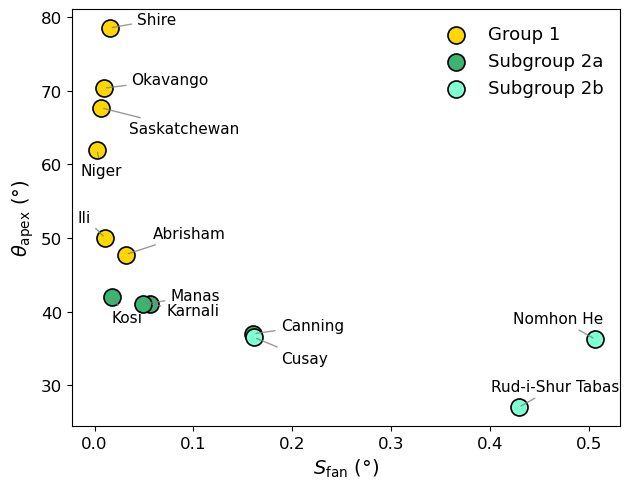

In [229]:
# ===============================================
# 1. Compute fan gradients from df2 (only if missing)
# ===============================================
if "gradient_df" not in globals() or "Fan Gradient (°)" not in globals().get("gradient_df", pd.DataFrame()).columns:
    print("⚙️ Recomputing fan gradients from df2...")
    df2["Distance_m"] = df2["Distance"] * 1000
    gradient_table = []

    for fan_name in df2["Fan"].unique():
        df_fan = df2[df2["Fan"] == fan_name].sort_values("Distance_m").copy()

        # Find Apex index
        apex_idx = df_fan[df_fan["Apex"] == "Apex"].index
        if len(apex_idx) == 0:
            print(f"⚠️ Warning: no Apex found for fan {fan_name}")
            continue
        apex_idx = apex_idx[0]

        # Drainage section (start → apex)
        drainage_dist = df_fan.loc[:apex_idx, "Distance_m"].values
        drainage_elev = df_fan.loc[:apex_idx, "River Elevation"].values
        drainage_slope_rad = np.gradient(drainage_elev, drainage_dist)
        drainage_slope_deg = np.degrees(np.mean(np.abs(drainage_slope_rad)))

        # Fan section (apex → end)
        fan_dist = df_fan.loc[apex_idx:, "Distance_m"].values
        fan_elev = df_fan.loc[apex_idx:, "River Elevation"].values
        fan_slope_rad = np.gradient(fan_elev, fan_dist)
        fan_slope_deg = np.degrees(np.mean(np.abs(fan_slope_rad)))

        gradient_table.append({
            "Fan": fan_name,
            "Drainage Gradient (°)": drainage_slope_deg,
            "Fan Gradient (°)": fan_slope_deg,
            "Gradient Ratio (Drainage/Fan)": drainage_slope_deg / fan_slope_deg if fan_slope_deg != 0 else np.nan
        })

    gradient_df = pd.DataFrame(gradient_table)
    print("✅ Gradient data computed.")
else:
    print("✅ Using existing gradient_df")

# ===============================================
# 2. Merge gradient data safely (without duplicates)
# ===============================================
df["Fan"] = df["Fan"].astype(str).str.strip()
gradient_df["Fan"] = gradient_df["Fan"].astype(str).str.strip()

if "Fan Gradient (°)" in df.columns:
    df = df.drop(columns=["Fan Gradient (°)"])

df = df.merge(
    gradient_df[["Fan", "Fan Gradient (°)"]],
    on="Fan",
    how="left",
    validate="m:1"
)
print("✅ Fan Gradient (°) merged successfully into df")

# ===============================================
# 3. Define group memberships (Group 1 / Subgroup 2a / 2b)
# ===============================================
group_1_fans = ["Niger", "Okavango", "Saskatchewan", "Shire", "Abrisham", "Ili"]
group_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
group_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

def assign_group(fan):
    if fan in group_1_fans:
        return "Group 1"
    elif fan in group_2a_fans:
        return "Subgroup 2a"
    elif fan in group_2b_fans:
        return "Subgroup 2b"
    else:
        return np.nan

df["Group"] = df["Fan"].apply(assign_group)
print("✅ Group assignments applied:")
print(df["Group"].dropna().unique())

# ===============================================
# 4. Filter Apex = Yes and summarize
# ===============================================
df_apex = df[df["Apex"].astype(str).str.lower() == "yes"].copy()

plot_df = (
    df_apex.groupby(["Fan", "Group"], as_index=False)
           .agg(mean_apex_angle=("Angle", "mean"),
                **{"Fan Gradient (°)": ("Fan Gradient (°)", "mean")})
)
plot_df = plot_df.dropna(subset=["mean_apex_angle", "Fan Gradient (°)"]).reset_index(drop=True)

# ===============================================
# 5. Label offsets (custom per fan)
# ===============================================
line_fans = {
    "Ili": {"dx": -0.05, "dy": 0.05},
    "Abrisham": {"dx": 0.05, "dy": 0.05},
    "Cusay": {"dx": 0.05, "dy": -0.05},
    "Niger": {"dx": -0.03, "dy": -0.05},
    "Saskatchewan": {"dx": 0.05, "dy": -0.05},
    "Kosi": {"dx": 0.0, "dy": -0.05},
    "Karnali": {"dx": 0.03, "dy": -0.015},
    "Nomhon He": {"dx": -0.15, "dy": 0.05},
    "Rud-i-Shur Tabas": {"dx": -0.05, "dy": 0.05},
}

# ===============================================
# 6. Plot settings
# ===============================================
colors = {
    "Group 1": "gold",
    "Subgroup 2a": "mediumseagreen",
    "Subgroup 2b": "aquamarine"
}
label_font, tick_font, legend_font, text_font = 14, 12, 13, 11
arrow_color = "gray"

# ===============================================
# 7. Smart label helper
# ===============================================
def smart_label(ax, x, y, fan, offsets=None, color="black"):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    dx = (offsets.get("dx", 0.05) if offsets else 0.05) * (xlim[1] - xlim[0])
    dy = (offsets.get("dy", 0.02) if offsets else 0.02) * (ylim[1] - ylim[0])
    ax.annotate(
        fan,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        fontsize=text_font,
        ha="left", va="center",
        color=color,
        arrowprops=dict(arrowstyle="-", lw=1.0, color=arrow_color, alpha=0.8),
    )

# ===============================================
# 8. Plot Mean Apex Angle vs Fan Gradient
# ===============================================
fig, ax = plt.subplots(figsize=(6.5, 5))

for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    data = plot_df[(plot_df["Group"] == group) & (plot_df["mean_apex_angle"].notna())]
    sns.scatterplot(
        data=data,
        x="Fan Gradient (°)",
        y="mean_apex_angle",
        s=150,
        color=colors.get(group, "gray"),
        edgecolor="black",
        linewidth=1.2,
        label=group,
        ax=ax
    )

ax.set_xlabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=label_font)
ax.set_ylabel(r"$\theta_{\mathrm{apex}}$ (°)", fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.legend(fontsize=legend_font, loc="upper right", frameon=False)
ax.grid(False)

# ===============================================
# 9. Add fan labels
# ===============================================
for _, row in plot_df.iterrows():
    if pd.notna(row["mean_apex_angle"]):
        offsets = line_fans.get(row["Fan"], None)
        smart_label(ax, row["Fan Gradient (°)"], row["mean_apex_angle"], row["Fan"], offsets=offsets)

plt.tight_layout()
plt.show()


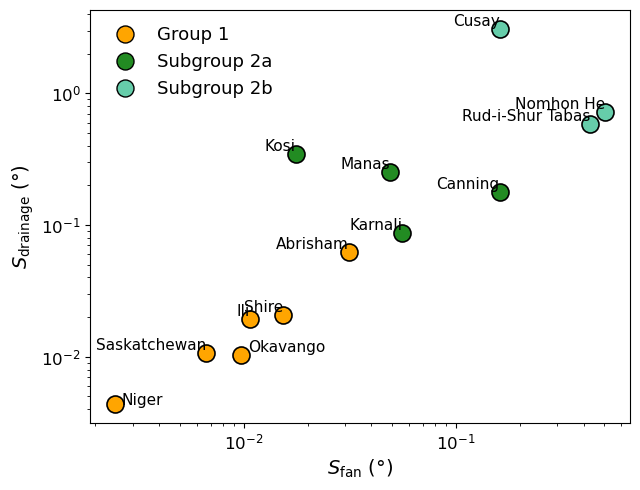

In [230]:
# =============================================
# Drainage Gradient vs Fan Gradient (by Group)
# =============================================

import matplotlib.lines as mlines  # ✅ Needed for custom legend handles

# ----------------------------------------
# Verify prerequisites
# ----------------------------------------
if "gradient_df" not in globals():
    raise ValueError("❌ gradient_df not found — please compute gradients first.")
if "Group" not in gradient_df.columns and "Group" not in df.columns:
    raise ValueError("❌ No group assignments found — please define df['Group'] first.")

# Ensure group column exists in gradient_df
if "Group" not in gradient_df.columns:
    gradient_df = gradient_df.merge(df[["Fan", "Group"]].drop_duplicates(), on="Fan", how="left")

# ----------------------------------------
# Plot setup
# ----------------------------------------
plt.figure(figsize=(6.5, 5))

colors = {
    "Group 1": "orange",
    "Subgroup 2a": "forestgreen",
    "Subgroup 2b": "mediumaquamarine"
}

# Scatter points
for group_name, group_color in colors.items():
    subset = gradient_df[gradient_df["Group"] == group_name]
    if subset.empty:
        continue

    plt.scatter(
        subset["Fan Gradient (°)"],
        subset["Drainage Gradient (°)"],
        s=150,
        color=group_color,
        edgecolor="black",
        linewidth=1.2,
        label=group_name
    )

# ----------------------------------------
# Add fan labels (manual adjustment for Niger & Okavango)
# ----------------------------------------
for _, row in gradient_df.iterrows():
    fan = row["Fan"]
    x = row["Fan Gradient (°)"]
    y = row["Drainage Gradient (°)"]
    if pd.isna(x) or pd.isna(y):
        continue

    if fan == "Niger":
        # 🔧 Slightly right and down
        plt.text(x * 1.08, y * 0.93, fan, fontsize=11, ha="left", va="bottom")
    elif fan == "Okavango":
        # 🔧 Slightly right
        plt.text(x * 2.5, y * 1.0, fan, fontsize=11, ha="right", va="bottom")
    else:
        plt.text(x, y, fan, fontsize=11, ha="right", va="bottom")

# ----------------------------------------
# Axis formatting
# ----------------------------------------
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=14)
plt.ylabel(r"$S_{\mathrm{drainage}}$ (°)", fontsize=14)
plt.tick_params(axis="both", labelsize=12)
plt.grid(False)

# ----------------------------------------
# Legend formatting (consistent with other plot)
# ----------------------------------------
handles = [
    mlines.Line2D([], [], color=colors["Group 1"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Group 1'),
    mlines.Line2D([], [], color=colors["Subgroup 2a"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2a'),
    mlines.Line2D([], [], color=colors["Subgroup 2b"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2b')
]

leg = plt.legend(handles=handles, fontsize=13, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()


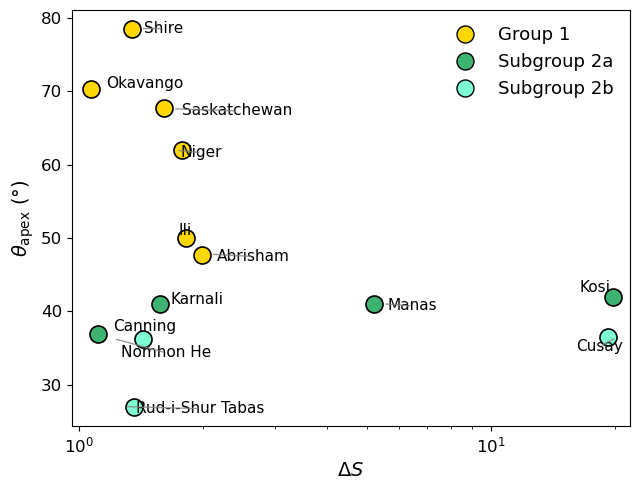

In [231]:
# =========================================================
# ΔS (Gradient Ratio) vs Mean Apex Angle Plot
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from adjustText import adjust_text
import numpy as np
import seaborn as sns
import pandas as pd

# --- Verify source DataFrames ---
if "gradient_df" not in globals():
    raise KeyError("gradient_df not found. Run the gradient computation first.")
if "df_apex" not in globals():
    raise KeyError("df_apex not found. Run the apex angle computation first.")

# --- Compute mean apex angle per fan ---
apex_summary = (
    df_apex.groupby(["Fan", "Group"], as_index=False)
           .agg(mean_apex_angle=("Angle", "mean"))
)

# --- Merge ΔS values with apex angles ---
need = ["Fan", "Gradient Ratio (Drainage/Fan)"]
missing = [c for c in need if c not in gradient_df.columns]
if missing:
    raise KeyError(f"Missing columns in gradient_df: {missing}")

plot_df = (
    gradient_df[["Fan", "Gradient Ratio (Drainage/Fan)"]]
    .merge(apex_summary, on="Fan", how="left")
    .rename(columns={"Gradient Ratio (Drainage/Fan)": "ΔS"})
    .dropna(subset=["ΔS", "mean_apex_angle", "Group"])
)
plot_df = plot_df[plot_df["ΔS"] > 0]

# --- Custom colors ---
colors = {
    "Group 1": "gold",
    "Subgroup 2a": "mediumseagreen",
    "Subgroup 2b": "aquamarine"
}

# --- Create the figure ---
fig, ax = plt.subplots(figsize=(6.5, 5))

for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    data = plot_df[plot_df["Group"] == group]
    sns.scatterplot(
        data=data,
        x="ΔS",
        y="mean_apex_angle",
        s=150,
        color=colors.get(group, "gray"),
        edgecolor="black",
        linewidth=1.2,
        label=group,
        ax=ax
    )

# --- Axes formatting ---
ax.set_xscale("log")
ax.set_xlabel(r"$\Delta S$", fontsize=label_font)
ax.set_ylabel(r"$\theta_{\mathrm{apex}}$ (°)", fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.grid(False)

# --- Axis limits ---
xvals = plot_df["ΔS"].values
yvals = plot_df["mean_apex_angle"].values
ax.set_xlim(xvals.min() * 0.9, xvals.max() * 1.1)
ypad = max(1.0, 0.05 * (yvals.max() - yvals.min()))
ax.set_ylim(yvals.min() - ypad, yvals.max() + ypad)

# --- Legend ---
handles = [
    mlines.Line2D([], [], color=colors["Group 1"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Group 1'),
    mlines.Line2D([], [], color=colors["Subgroup 2a"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2a'),
    mlines.Line2D([], [], color=colors["Subgroup 2b"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2b')
]
ax.legend(handles=handles, fontsize=legend_font, loc="upper right", frameon=False)

# --- Fan label annotations ---
texts = []
for _, row in plot_df.iterrows():
    offsets = line_fans.get(row["Fan"], {"dx": 0.05, "dy": 0.05})
    dx = offsets.get("dx", 0.05)
    dy = offsets.get("dy", 0.05)
    texts.append(
        ax.text(
            row["ΔS"] * (1 + dx),
            row["mean_apex_angle"] + dy,
            row["Fan"],
            fontsize=text_font,
            color="black",
            ha="left",
            va="center"
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", lw=1.0, color="gray", alpha=0.8),
    only_move={'points': 'y', 'text': 'y'},
    force_points=0.3,
    force_text=0.5,
    expand_text=(1.05, 1.2),
    lim=100
)

plt.tight_layout()
plt.show()


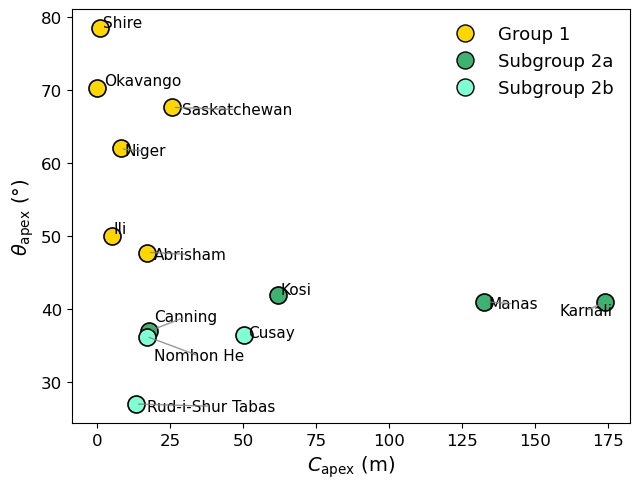

In [232]:
# =========================================================
# Confinement Loss (avg of last 3 topo) − (avg of last 3 river), pre-apex
# =========================================================
from adjustText import adjust_text
import matplotlib.lines as mlines

# --- Compute per-fan confinement loss with the 3-node averaging rule ---
conf_table = []

for fan_name in df2["Fan"].unique():
    sub = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .loc[~df2[df2["Fan"] == fan_name]["Distance"].duplicated()]
        .reset_index(drop=True)
        .copy()
    )

    # Find apex index
    apex_idx_list = sub.index[sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])].tolist()
    if not apex_idx_list:
        print(f"⚠️ No Apex found for {fan_name}")
        continue
    apex_idx = apex_idx_list[0]

    # Slice the last up-to-3 rows before apex
    start_idx = max(apex_idx - 3, 0)
    pre_apex = sub.iloc[start_idx:apex_idx].copy()

    if pre_apex.empty:
        print(f"⚠️ No pre-apex nodes for {fan_name}")
        continue

    # Explicit: mean of topo minus mean of river
    mean_topo = pre_apex["Mean Elevation"].mean()
    mean_river = pre_apex["River Elevation"].mean()
    conf_loss = mean_topo - mean_river  # meters

    conf_table.append({
        "Fan": fan_name,
        "Confinement Loss (m)": conf_loss,
        "N_nodes_used": len(pre_apex)
    })

conf_df = pd.DataFrame(conf_table)

# --- Merge with mean apex angles ---
conf_plot_df = (
    df_apex.groupby(["Fan", "Group"], as_index=False)
           .agg(mean_apex_angle=("Angle", "mean"))
           .merge(conf_df, on="Fan", how="left")
           .dropna(subset=["Confinement Loss (m)", "mean_apex_angle"])
           .reset_index(drop=True)
)

# =========================================================
# Plot: Confinement Loss (3-node mean) vs Mean Apex Angle
# =========================================================
fig, ax = plt.subplots(figsize=(6.5, 5))

# --- Set your custom colors here ---
colors = {
    "Group 1": "gold",
    "Subgroup 2a": "mediumseagreen",
    "Subgroup 2b": "aquamarine"
}

for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    data = conf_plot_df[conf_plot_df["Group"] == group]
    sns.scatterplot(
        data=data,
        x="Confinement Loss (m)",
        y="mean_apex_angle",
        s=150,
        color=colors.get(group, "gray"),
        edgecolor="black",
        linewidth=1.2,
        label=group,
        ax=ax
    )

ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=label_font)
ax.set_ylabel(r"$\theta_{\mathrm{apex}}$ (°)", fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.grid(False)

# --- Legend (consistent with your other plots) ---
handles = [
    mlines.Line2D([], [], color=colors["Group 1"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Group 1'),
    mlines.Line2D([], [], color=colors["Subgroup 2a"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2a'),
    mlines.Line2D([], [], color=colors["Subgroup 2b"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2b')
]
ax.legend(handles=handles, fontsize=legend_font, loc="upper right", frameon=False)

# --- Labels with automatic overlap avoidance ---
texts = []
for _, row in conf_plot_df.iterrows():
    offsets = line_fans.get(row["Fan"], {"dx": 0.05, "dy": 0.05})
    dx = offsets.get("dx", 0.05)
    dy = offsets.get("dy", 0.05)
    texts.append(
        ax.text(
            row["Confinement Loss (m)"] + dx,
            row["mean_apex_angle"] + dy,
            row["Fan"],
            fontsize=text_font,
            color="black",
            ha="left",
            va="center"
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", lw=1.0, color="gray", alpha=0.8),
    only_move={'points': 'y', 'text': 'y'},
    force_points=0.3,
    force_text=0.5,
    expand_text=(1.05, 1.2),
    lim=100
)

plt.tight_layout()
plt.show()


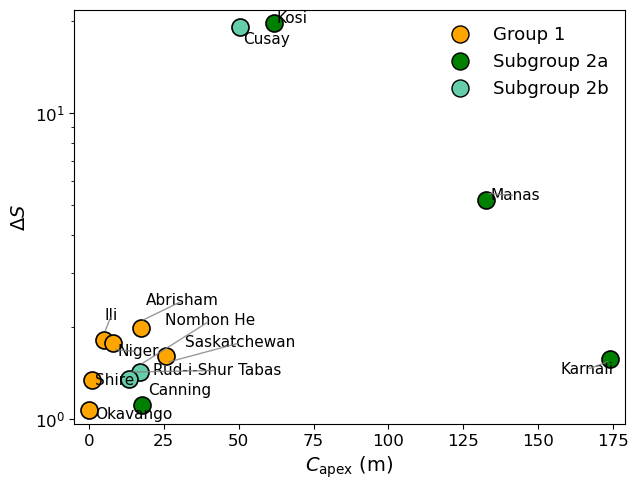

In [233]:
# =========================================================
# Confinement Loss (mean over last 3 km pre-apex)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.lines as mlines

conf_table = []

for fan_name in df2["Fan"].unique():
    sub = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .copy()
    )

    # --- locate apex index ---
    apex_idx_list = sub.index[sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])].tolist()
    if not apex_idx_list:
        print(f"⚠️ No Apex found for {fan_name}")
        continue
    apex_idx = apex_idx_list[0]
    apex_dist = sub.loc[apex_idx, "Distance"]

    # --- select nodes strictly before apex, within 3 km upstream ---
    pre_apex = sub[(sub["Distance"] < apex_dist) & (sub["Distance"] >= (apex_dist - 3))].copy()

    if pre_apex.empty:
        print(f"⚠️ No pre-apex nodes within 3 km for {fan_name}")
        continue

    mean_topo = pre_apex["Mean Elevation"].mean()
    mean_river = pre_apex["River Elevation"].mean()
    conf_loss = mean_topo - mean_river  # meters

    conf_table.append({
        "Fan": fan_name,
        "Confinement Loss (m)": conf_loss,
        "Distance window (km)": 3,
        "N_nodes_used": len(pre_apex)
    })

conf_df = pd.DataFrame(conf_table)

# ------------------------------------------------
# Merge with gradient ratio (ΔS)
# ------------------------------------------------
plot_df = (
    conf_df.merge(gradient_df[["Fan", "Gradient Ratio (Drainage/Fan)"]],
                  on="Fan", how="left")
           .rename(columns={"Gradient Ratio (Drainage/Fan)": "ΔS"})
           .dropna(subset=["Confinement Loss (m)", "ΔS"])
)

# ------------------------------------------------
# Assign groups
# ------------------------------------------------
def assign_group(f):
    if f in ["Niger","Okavango","Saskatchewan","Shire","Abrisham","Ili"]: return "Group 1"
    if f in ["Canning","Karnali","Kosi","Manas"]: return "Subgroup 2a"
    if f in ["Nomhon He","Rud-i-Shur Tabas","Cusay"]: return "Subgroup 2b"
    return np.nan

plot_df["Group"] = plot_df["Fan"].apply(assign_group)
plot_df = plot_df.dropna(subset=["Group"])

# ------------------------------------------------
# Plot: ΔS vs Confinement Loss (3 km mean)
# ------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(6.5, 5))

# Custom colors
colors = {
    "Group 1": "orange",
    "Subgroup 2a": "green",
    "Subgroup 2b": "mediumaquamarine"
}

# Scatter by group
for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    sub = plot_df[plot_df["Group"] == group]
    if sub.empty:
        continue
    ax.scatter(
        sub["Confinement Loss (m)"],
        sub["ΔS"],
        s=150,
        c=colors.get(group, "gray"),
        edgecolors="black",
        linewidths=1.2,
        label=group,
        zorder=3
    )

# --- Axis setup ---
ax.set_yscale("log")
yvals = plot_df["ΔS"].values
xvals = plot_df["Confinement Loss (m)"].values
ax.set_xlim(xvals.min() - 5, xvals.max() + 5)
ax.set_ylim(yvals.min() * 0.9, yvals.max() * 1.1)

ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=label_font)
ax.set_ylabel(r"$\Delta S$", fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.grid(False)

# --- Legend (consistent style) ---
handles = [
    mlines.Line2D([], [], color=colors["Group 1"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Group 1'),
    mlines.Line2D([], [], color=colors["Subgroup 2a"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2a'),
    mlines.Line2D([], [], color=colors["Subgroup 2b"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2b')
]
ax.legend(handles=handles, fontsize=legend_font, loc="upper right", frameon=False)

# --- Add fan labels ---
texts = []
for _, row in plot_df.iterrows():
    offs = line_fans.get(row["Fan"], {"dx": 0.05, "dy": 0.05})
    texts.append(
        ax.text(
            row["Confinement Loss (m)"] + offs.get("dx", 0.05),
            row["ΔS"] * (1 + offs.get("dy", 0.05)),
            row["Fan"],
            fontsize=text_font,
            color="black",
            ha="left",
            va="center"
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", lw=1.0, color="gray", alpha=0.8),
    only_move={'points': 'y', 'text': 'y'},
    force_points=0.3,
    force_text=0.5,
    expand_text=(1.05, 1.2),
    lim=100
)

plt.tight_layout()
plt.show()


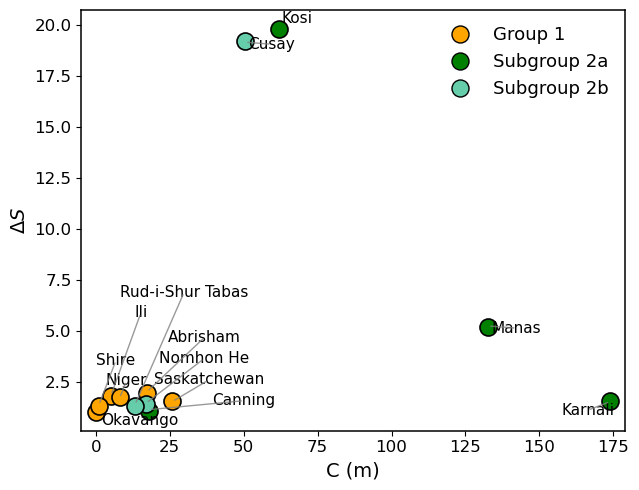

In [234]:
import matplotlib.lines as mlines

conf_table = []

# ------------------------------------------------
# Compute confinement loss for each fan (3 km pre-apex)
# ------------------------------------------------
for fan_name in df2["Fan"].unique():
    sub = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .copy()
    )

    # --- locate apex index ---
    apex_idx_list = sub.index[sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])].tolist()
    if not apex_idx_list:
        print(f"⚠️ No Apex found for {fan_name}")
        continue
    apex_idx = apex_idx_list[0]
    apex_dist = sub.loc[apex_idx, "Distance"]

    # --- select nodes strictly before apex, within 3 km upstream ---
    pre_apex = sub[(sub["Distance"] < apex_dist) & (sub["Distance"] >= (apex_dist - 3))].copy()

    if pre_apex.empty:
        print(f"⚠️ No pre-apex nodes within 3 km for {fan_name}")
        continue

    mean_topo = pre_apex["Mean Elevation"].mean()
    mean_river = pre_apex["River Elevation"].mean()
    conf_loss = mean_topo - mean_river  # meters

    conf_table.append({
        "Fan": fan_name,
        "Confinement Loss (m)": conf_loss,
        "Distance window (km)": 3,
        "N_nodes_used": len(pre_apex)
    })

conf_df = pd.DataFrame(conf_table)

# ------------------------------------------------
# Merge with gradient ratio (ΔS)
# ------------------------------------------------
plot_df = (
    conf_df.merge(gradient_df[["Fan", "Gradient Ratio (Drainage/Fan)"]],
                  on="Fan", how="left")
           .rename(columns={"Gradient Ratio (Drainage/Fan)": "ΔS"})
           .dropna(subset=["Confinement Loss (m)", "ΔS"])
)

# ------------------------------------------------
# Assign groups
# ------------------------------------------------
def assign_group(f):
    if f in ["Niger","Okavango","Saskatchewan","Shire","Abrisham","Ili"]: return "Group 1"
    if f in ["Canning","Karnali","Kosi","Manas"]: return "Subgroup 2a"
    if f in ["Nomhon He","Rud-i-Shur Tabas","Cusay"]: return "Subgroup 2b"
    return np.nan

plot_df["Group"] = plot_df["Fan"].apply(assign_group)
plot_df = plot_df.dropna(subset=["Group"])

# ------------------------------------------------
# Plot: ΔS vs Confinement Loss (3 km mean)
# ------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(6.5, 5))

# Custom colors (consistent)
colors = {
    "Group 1": "orange",
    "Subgroup 2a": "green",
    "Subgroup 2b": "mediumaquamarine"
}

# Scatter by group
for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    sub = plot_df[plot_df["Group"] == group]
    if sub.empty:
        continue
    ax.scatter(
        sub["Confinement Loss (m)"],
        sub["ΔS"],
        s=150,
        c=colors.get(group, "gray"),
        edgecolors="black",
        linewidths=1.2,
        label=group,
        zorder=3
    )

# --- Axis setup (no log scale) ---
xvals = plot_df["Confinement Loss (m)"].values
yvals = plot_df["ΔS"].values
ax.set_xlim(xvals.min() - 5, xvals.max() + 5)
ypad = 0.05 * (yvals.max() - yvals.min())
ax.set_ylim(yvals.min() - ypad, yvals.max() + ypad)

ax.set_xlabel(r"C (m)", fontsize=label_font)
ax.set_ylabel(r"$\Delta S$", fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.grid(False)

# --- Legend (consistent with your style) ---
handles = [
    mlines.Line2D([], [], color=colors["Group 1"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Group 1'),
    mlines.Line2D([], [], color=colors["Subgroup 2a"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2a'),
    mlines.Line2D([], [], color=colors["Subgroup 2b"], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label='Subgroup 2b')
]
ax.legend(handles=handles, fontsize=legend_font, loc="upper right", frameon=False)

# --- Add fan labels ---
texts = []
for _, row in plot_df.iterrows():
    offs = line_fans.get(row["Fan"], {"dx": 0.05, "dy": 0.05})
    texts.append(
        ax.text(
            row["Confinement Loss (m)"] + offs.get("dx", 0.05),
            row["ΔS"] + offs.get("dy", 0.05),
            row["Fan"],
            fontsize=text_font,
            color="black",
            ha="left",
            va="center"
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", lw=1.0, color="gray", alpha=0.8),
    only_move={'points': 'y', 'text': 'y'},
    force_points=0.3,
    force_text=0.5,
    expand_text=(1.05, 1.2),
    lim=100
)

# --- Box outline ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color("black")

plt.tight_layout()
plt.show()


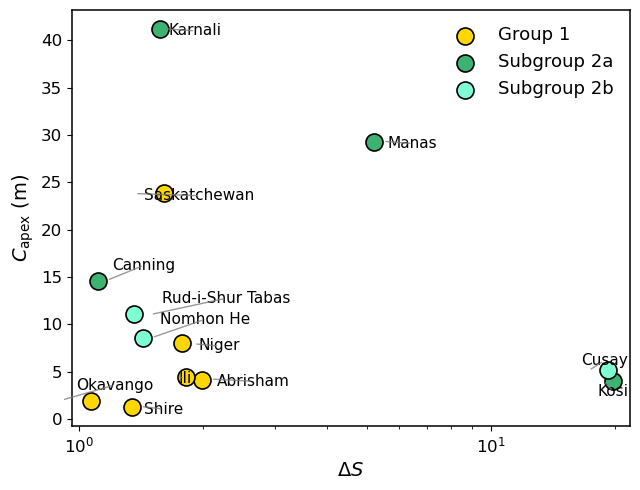

In [235]:
# ===============================================
# C_apex (single-node confinement loss) vs ΔS (gradient ratio)
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ------------------------------------------------
# 1. Compute confinement loss at the apex (single node)
# ------------------------------------------------
conf_table = []

for fan_name in df2["Fan"].unique():
    sub = df2[df2["Fan"] == fan_name].copy()
    apex_row = sub[sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])]

    if apex_row.empty:
        print(f"⚠️ No Apex found for {fan_name}")
        continue

    topo_elev = apex_row["Mean Elevation"].values[0]      # surface elevation
    river_elev = apex_row["River Elevation"].values[0]    # channel elevation
    confinement_loss = topo_elev - river_elev             # m

    conf_table.append({
        "Fan": fan_name,
        "Confinement Loss (m)": confinement_loss
    })

conf_df = pd.DataFrame(conf_table)

# ------------------------------------------------
# 2. Merge with gradient ratio (ΔS)
# ------------------------------------------------
if "gradient_df" not in globals():
    raise KeyError("❌ gradient_df not found. Please run the gradient computation first.")

plot_df = (
    conf_df.merge(gradient_df[["Fan", "Gradient Ratio (Drainage/Fan)"]], on="Fan", how="left")
           .rename(columns={"Gradient Ratio (Drainage/Fan)": "ΔS"})
           .dropna(subset=["Confinement Loss (m)", "ΔS"])
)

# ------------------------------------------------
# 3. Assign groups
# ------------------------------------------------
def assign_group(f):
    if f in ["Niger","Okavango","Saskatchewan","Shire","Abrisham","Ili"]: return "Group 1"
    if f in ["Canning","Karnali","Kosi","Manas"]: return "Subgroup 2a"
    if f in ["Nomhon He","Rud-i-Shur Tabas","Cusay"]: return "Subgroup 2b"
    return np.nan

plot_df["Group"] = plot_df["Fan"].apply(assign_group)
plot_df = plot_df.dropna(subset=["Group"])
plot_df = plot_df[plot_df["ΔS"] > 0]  # log-safe

# ------------------------------------------------
# 4. Plot settings
# ------------------------------------------------
colors = {
    "Group 1": "gold",
    "Subgroup 2a": "mediumseagreen",
    "Subgroup 2b": "aquamarine"
}
label_font, tick_font, legend_font, text_font = 14, 12, 13, 11
arrow_color = "gray"

# Label offsets
line_fans = {
    "Ili": {"dx": -0.05, "dy": 0.05},
    "Abrisham": {"dx": 0.05, "dy": 0.05},
    "Cusay": {"dx": -0.1, "dy": -0.05},
    "Niger": {"dx": 0.07, "dy": -0.05},
    "Saskatchewan": {"dx": -0.15, "dy": -0.05},
    "Shire": {"dx": 0.05, "dy": 0.05},
    "Kosi": {"dx": -0.05, "dy": 0.05},
    "Karnali": {"dx": 0.02, "dy": 0.02},
    "Nomhon He": {"dx": 0.05, "dy": 0.05},
    "Okavango": {"dx": -0.15, "dy": 0.05},
    "Rud-i-Shur Tabas": {"dx": 0.1, "dy": 0.0},
}

# ------------------------------------------------
# 5. Create figure
# ------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(6.5, 5))

for group in ["Group 1","Subgroup 2a","Subgroup 2b"]:
    sub = plot_df[plot_df["Group"] == group]
    if sub.empty: 
        continue
    ax.scatter(
        sub["ΔS"],
        sub["Confinement Loss (m)"],
        s=150,
        c=colors.get(group,"gray"),
        edgecolors="black",
        linewidths=1.2,
        label=group,
        zorder=3
    )

# ------------------------------------------------
# 6. Axes formatting
# ------------------------------------------------
ax.set_xscale("log")

xvals = plot_df["ΔS"].values
yvals = plot_df["Confinement Loss (m)"].values
ax.set_xlim(xvals.min()*0.9, xvals.max()*1.1)
ypad = max(1.0, 0.05*(yvals.max()-yvals.min()))
ax.set_ylim(yvals.min()-ypad, yvals.max()+ypad)

ax.set_xlabel(r"$\Delta S$", fontsize=label_font)
ax.set_ylabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=label_font)

ax.tick_params(axis="both", labelsize=tick_font)
ax.legend(fontsize=legend_font, loc="upper right", frameon=False)
ax.grid(False)

# Restore full box outline
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color("black")

# ------------------------------------------------
# 7. Add fan labels with adjust_text
# ------------------------------------------------
texts = []
for _, row in plot_df.iterrows():
    offs = line_fans.get(row["Fan"], {"dx": 0.05, "dy": 0.05})
    texts.append(
        ax.text(
            row["ΔS"] * (1 + offs.get("dx", 0.05)),
            row["Confinement Loss (m)"] + offs.get("dy", 0.05),
            row["Fan"],
            fontsize=text_font,
            color="black",
            ha="left",
            va="center"
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", lw=1.0, color=arrow_color, alpha=0.8),
    only_move={'points': 'y', 'text': 'y'},
    force_points=0.3,
    force_text=0.5,
    expand_text=(1.05, 1.2),
    lim=100
)

plt.tight_layout()
plt.show()



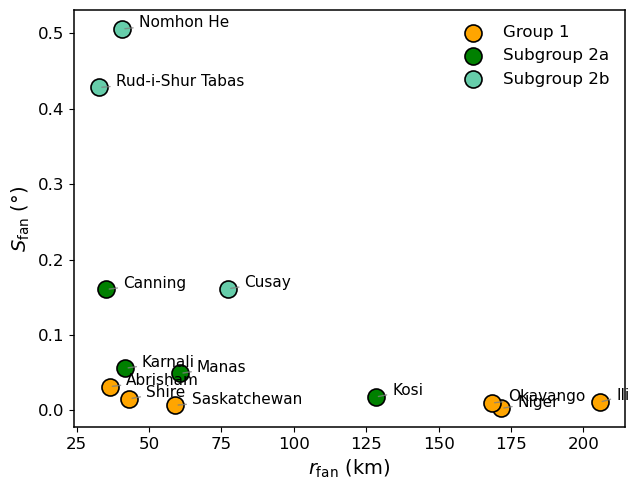

In [236]:
# -----------------------------------------------------
# Fan Length (r_fan) vs Fan Gradient (S_fan)
# -----------------------------------------------------

# --- Verify prerequisites ---
if not all(x in globals() for x in ["apex_coords", "toe_coords", "gradient_df", "assign_group", "colors"]):
    raise ValueError("❌ Missing one of the required variables: apex_coords, toe_coords, gradient_df, assign_group, colors")

# --- Haversine (great-circle distance) ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# --- Build DataFrame of lengths and gradients ---
fan_records = []
for fan in apex_coords.keys():
    if fan not in toe_coords:
        print(f"⚠️ Skipping {fan} — missing toe coordinates.")
        continue

    lat1, lon1 = apex_coords[fan]
    lat2, lon2 = toe_coords[fan]
    length_km = haversine(lat1, lon1, lat2, lon2) / 1000  # km

    grad_val = np.nan
    if "Fan Gradient (°)" in gradient_df.columns:
        row = gradient_df.loc[gradient_df["Fan"] == fan]
        if not row.empty:
            grad_val = row["Fan Gradient (°)"].iloc[0]

    fan_records.append({
        "Fan": fan,
        "Group": assign_group(fan),
        "r_fan (km)": length_km,
        "S_fan (°)": grad_val
    })

plot_df = pd.DataFrame(fan_records).dropna(subset=["S_fan (°)"])

# --- Labeling helper ---
def smart_label(ax, x, y, fan, offsets=None, color="black"):
    ax.figure.canvas.draw()
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    dx_base = 0.03 * (xlim[1] - xlim[0])
    dy_base = 0.015 * (ylim[1] - ylim[0])
    if offsets:
        dx_scaled = offsets.get("dx", 0.03) * (xlim[1] - xlim[0])
        dy_scaled = offsets.get("dy", 0.015) * (ylim[1] - ylim[0])
    else:
        dx_scaled, dy_scaled = dx_base, dy_base
    ax.annotate(
        fan,
        xy=(x, y),
        xytext=(x + dx_scaled, y + dy_scaled),
        fontsize=11,
        ha="left",
        va="center",
        color=color,
        arrowprops=dict(arrowstyle="-", lw=1.0, color="gray", alpha=0.8)
    )

# --- Plot ---
fig, ax = plt.subplots(figsize=(6.5, 5))

# Custom consistent colors
colors = {
    "Group 1": "orange",
    "Subgroup 2a": "green",
    "Subgroup 2b": "mediumaquamarine"
}

# --- Scatter points ---
for group, color in colors.items():
    subset = plot_df[plot_df["Group"] == group]
    if subset.empty:
        continue
    sns.scatterplot(
        data=subset,
        x="r_fan (km)",
        y="S_fan (°)",
        s=150,
        color=color,
        edgecolor="black",
        linewidth=1.2,
        label=group,
        ax=ax
    )

# --- Labels ---
for _, row in plot_df.iterrows():
    smart_label(ax, row["r_fan (km)"], row["S_fan (°)"], row["Fan"])

# --- Formatting ---
ax.set_xlabel(r"$r_{\mathrm{fan}}$ (km)", fontsize=14)
ax.set_ylabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12, frameon=False, loc="upper right")
ax.grid(False)

# --- Optional: full box outline for consistency ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color("black")

plt.tight_layout()
plt.show()


In [237]:
### Not used

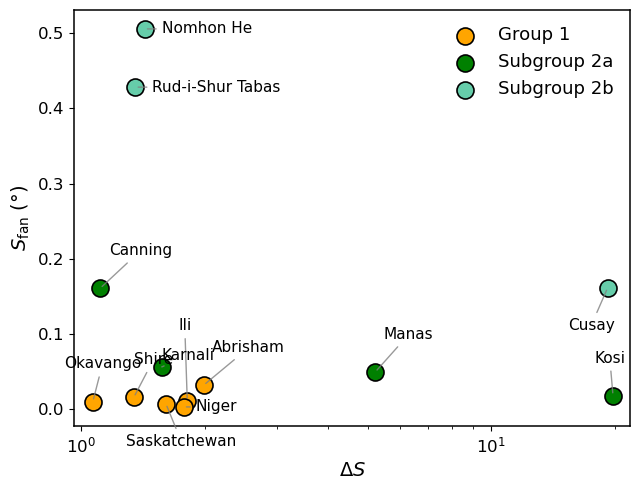

In [102]:
# ===============================================
# Gradient Change (ΔS) vs Fan Gradient Plot
# ===============================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. Checks & input
# ------------------------------------------------
if "gradient_df" not in globals():
    raise KeyError("gradient_df not found. Run the gradient computation first.")

need = ["Fan", "Fan Gradient (°)", "Gradient Ratio (Drainage/Fan)"]
missing = [c for c in need if c not in gradient_df.columns]
if missing:
    raise KeyError(f"Missing columns in gradient_df: {missing}")

# ------------------------------------------------
# 2. Define groupings and style parameters
# ------------------------------------------------
group_1_fans = ["Niger", "Okavango", "Saskatchewan", "Shire", "Abrisham", "Ili"]
group_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
group_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

def assign_group(f):
    if f in group_1_fans: return "Group 1"
    if f in group_2a_fans: return "Subgroup 2a"
    if f in group_2b_fans: return "Subgroup 2b"
    return np.nan

colors = {
    "Group 1": "orange",
    "Subgroup 2a": "green",
    "Subgroup 2b": "mediumaquamarine"
}

label_font, tick_font, legend_font, text_font = 14, 12, 13, 11
arrow_color = "gray"

# ------------------------------------------------
# 3. Label offset dictionary (tuned for this plot)
# ------------------------------------------------
line_fans = {
    "Ili": {"dx": -0.05, "dy": 0.1},
    "Abrisham": {"dx": 0.05, "dy": 0.05},
    "Cusay": {"dx": -.2, "dy": -0.05},
    "Niger": {"dx": 0.07, "dy": 0},
    "Saskatchewan": {"dx": -0.2, "dy": -0.05},
    "Shire": {"dx": 0., "dy": 0.05},
    "Kosi": {"dx":  -0.1, "dy": 0.05},
    "Karnali": {"dx": 0., "dy": 0.015},
    "Nomhon He": {"dx": 0.1, "dy": 0.0},
    "Okavango": {"dx": -0.15, "dy": 0.05},
    "Rud-i-Shur Tabas": {"dx": 0.1, "dy": 0},
}

# ------------------------------------------------
# 4. Build plotting DataFrame
# ------------------------------------------------
plot_df = gradient_df.copy()
plot_df["Fan"] = plot_df["Fan"].astype(str).str.strip()
plot_df["Group"] = plot_df["Fan"].apply(assign_group)
plot_df = plot_df.rename(columns={"Gradient Ratio (Drainage/Fan)": "ΔS"})
plot_df = plot_df.dropna(subset=["ΔS", "Fan Gradient (°)", "Group"])
plot_df = plot_df[plot_df["ΔS"] > 0]  # log-safe
if plot_df.empty:
    raise ValueError("No valid rows (ΔS>0 and Fan Gradient present) to plot.")

# ------------------------------------------------
# 5. Make the plot
# ------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(6.5, 5))

for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    sub = plot_df[plot_df["Group"] == group]
    if sub.empty: 
        continue
    ax.scatter(
        sub["ΔS"].values,
        sub["Fan Gradient (°)"].values,
        s=150,
        c=colors.get(group, "gray"),
        edgecolors="black",
        linewidths=1.2,
        label=group,
        zorder=3
    )

# ------------------------------------------------
# 6. Axes and formatting
# ------------------------------------------------
ax.set_xscale("log")

xvals = plot_df["ΔS"].values
yvals = plot_df["Fan Gradient (°)"].values
ax.set_xlim(xvals.min() * 0.9, xvals.max() * 1.1)
ypad = max(0.005, 0.05 * (yvals.max() - yvals.min()))
ax.set_ylim(yvals.min() - ypad, yvals.max() + ypad)

ax.set_xlabel(r"$\Delta S$", fontsize=label_font)
ax.set_ylabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=label_font)

ax.tick_params(axis="both", labelsize=tick_font)
ax.legend(fontsize=legend_font, loc="upper right", frameon=False)
ax.grid(False)

# Restore full box outline
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color("black")

# ------------------------------------------------
# 7. Add fan labels (multiplicative x-offset for log scale)
# ------------------------------------------------
for _, r in plot_df.iterrows():
    offs = line_fans.get(r["Fan"], {"dx": 0.05, "dy": 0.05})
    ax.annotate(
        r["Fan"],
        xy=(r["ΔS"], r["Fan Gradient (°)"]),
        xytext=(r["ΔS"] * (1 + offs.get("dx", 0.05)), 
                r["Fan Gradient (°)"] + offs.get("dy", 0.05)),
        fontsize=text_font,
        color="black",
        ha="left", va="center",
        arrowprops=dict(arrowstyle="-", lw=1.0, color=arrow_color, alpha=0.8),
        zorder=4
    )

plt.tight_layout()
plt.show()


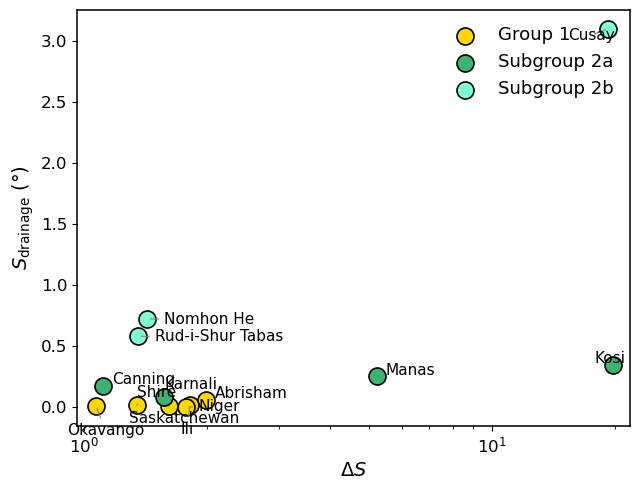

In [103]:
# ===============================================
# Gradient Change (ΔS) vs Drainage Gradient Plot
# ===============================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. Checks & input
# ------------------------------------------------
if "gradient_df" not in globals():
    raise KeyError("gradient_df not found. Run the gradient computation first.")

need = ["Fan", "Drainage Gradient (°)", "Gradient Ratio (Drainage/Fan)"]
missing = [c for c in need if c not in gradient_df.columns]
if missing:
    raise KeyError(f"Missing columns in gradient_df: {missing}")

# ------------------------------------------------
# 2. Define groupings and style parameters
# ------------------------------------------------
group_1_fans = ["Niger", "Okavango", "Saskatchewan", "Shire", "Abrisham", "Ili"]
group_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
group_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

def assign_group(f):
    if f in group_1_fans: return "Group 1"
    if f in group_2a_fans: return "Subgroup 2a"
    if f in group_2b_fans: return "Subgroup 2b"
    return np.nan

colors = {
    "Group 1": "gold",
    "Subgroup 2a": "mediumseagreen",
    "Subgroup 2b": "aquamarine"
}

label_font, tick_font, legend_font, text_font = 14, 12, 13, 11
arrow_color = "gray"

# ------------------------------------------------
# 3. Label offset dictionary (same offsets)
# ------------------------------------------------
line_fans = {
    "Ili": {"dx": -0.05, "dy": -0.2},
    "Abrisham": {"dx": 0.05, "dy": 0.05},
    "Cusay": {"dx": -0.2, "dy": -0.05},
    "Niger": {"dx": 0.07, "dy": 0},
    "Saskatchewan": {"dx": -0.2, "dy": -0.1},
    "Shire": {"dx": 0., "dy": 0.1},
    "Kosi": {"dx": -0.1, "dy": 0.05},
    "Karnali": {"dx": 0., "dy": 0.1},
    "Nomhon He": {"dx": 0.1, "dy": 0.0},
    "Okavango": {"dx": -0.15, "dy": -0.2},
    "Rud-i-Shur Tabas": {"dx": 0.1, "dy": 0},
}

# ------------------------------------------------
# 4. Build plotting DataFrame
# ------------------------------------------------
plot_df = gradient_df.copy()
plot_df["Fan"] = plot_df["Fan"].astype(str).str.strip()
plot_df["Group"] = plot_df["Fan"].apply(assign_group)
plot_df = plot_df.rename(columns={"Gradient Ratio (Drainage/Fan)": "ΔS"})
plot_df = plot_df.dropna(subset=["ΔS", "Drainage Gradient (°)", "Group"])
plot_df = plot_df[plot_df["ΔS"] > 0]  # log-safe
if plot_df.empty:
    raise ValueError("No valid rows (ΔS>0 and Drainage Gradient present) to plot.")

# ------------------------------------------------
# 5. Make the plot
# ------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(6.5, 5))

for group in ["Group 1", "Subgroup 2a", "Subgroup 2b"]:
    sub = plot_df[plot_df["Group"] == group]
    if sub.empty: 
        continue
    ax.scatter(
        sub["ΔS"].values,
        sub["Drainage Gradient (°)"].values,
        s=150,
        c=colors.get(group, "gray"),
        edgecolors="black",
        linewidths=1.2,
        label=group,
        zorder=3
    )

# ------------------------------------------------
# 6. Axes and formatting
# ------------------------------------------------
ax.set_xscale("log")

xvals = plot_df["ΔS"].values
yvals = plot_df["Drainage Gradient (°)"].values
ax.set_xlim(xvals.min() * 0.9, xvals.max() * 1.1)
ypad = max(0.005, 0.05 * (yvals.max() - yvals.min()))
ax.set_ylim(yvals.min() - ypad, yvals.max() + ypad)

ax.set_xlabel(r"$\Delta S$", fontsize=label_font)
ax.set_ylabel(r"$S_{\mathrm{drainage}}$ (°)", fontsize=label_font)

ax.tick_params(axis="both", labelsize=tick_font)
ax.legend(fontsize=legend_font, loc="upper right", frameon=False)
ax.grid(False)

# Restore full box outline
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color("black")

# ------------------------------------------------
# 7. Add fan labels (multiplicative x-offset for log scale)
# ------------------------------------------------
for _, r in plot_df.iterrows():
    offs = line_fans.get(r["Fan"], {"dx": 0.05, "dy": 0.05})
    ax.annotate(
        r["Fan"],
        xy=(r["ΔS"], r["Drainage Gradient (°)"]),
        xytext=(r["ΔS"] * (1 + offs.get("dx", 0.05)), 
                r["Drainage Gradient (°)"] + offs.get("dy", 0.05)),
        fontsize=text_font,
        color="black",
        ha="left", va="center",
        arrowprops=dict(arrowstyle="-", lw=1.0, color=arrow_color, alpha=0.8),
        zorder=4
    )

plt.tight_layout()
plt.show()


In [109]:
# =========================================================
# Confinement metrics per fan:
# C_apex = topo − river at apex
# C_3node = mean(topos - rivers) of 3 pre-apex nodes
# C_5node = mean(topos - rivers) of 5 pre-apex nodes
# =========================================================

conf_summary = []

for fan_name in df2["Fan"].unique():
    sub = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .loc[~df2[df2["Fan"] == fan_name]["Distance"].duplicated()]
        .reset_index(drop=True)
        .copy()
    )

    # Find apex index
    apex_idx_list = sub.index[sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])].tolist()
    if not apex_idx_list:
        print(f"⚠️ No Apex found for {fan_name}")
        continue
    apex_idx = apex_idx_list[0]

    # --- Apex-only confinement
    apex_row = sub.iloc[apex_idx]
    C_apex = apex_row["Mean Elevation"] - apex_row["River Elevation"]

    # --- 3-node mean pre-apex
    start_3 = max(apex_idx - 3, 0)
    pre3 = sub.iloc[start_3:apex_idx].copy()
    C_3node = (pre3["Mean Elevation"].mean() - pre3["River Elevation"].mean()) if not pre3.empty else np.nan

    # --- 5-node mean pre-apex
    start_5 = max(apex_idx - 5, 0)
    pre5 = sub.iloc[start_5:apex_idx].copy()
    C_5node = (pre5["Mean Elevation"].mean() - pre5["River Elevation"].mean()) if not pre5.empty else np.nan

    conf_summary.append({
        "Fan": fan_name,
        "C_apex (m)": round(C_apex, 2),
        "C 3-km mean (m)": round(C_3node, 2),
        "C 5-km mean (m)": round(C_5node, 2)
    })

# --- Convert to DataFrame
conf_summary_df = pd.DataFrame(conf_summary).sort_values("Fan").reset_index(drop=True)

# --- Display neatly
pd.set_option("display.float_format", "{:,.2f}".format)
print(conf_summary_df)


                 Fan  C_apex (m)  C 3-km mean (m)  C 5-km mean (m)
0           Abrisham        4.17            17.22            18.15
1            Canning       14.59            17.87            21.94
2              Cusay        5.17            50.39            80.13
3                Ili        4.47             5.15             5.30
4            Karnali       41.19           173.90           236.29
5               Kosi        3.99            61.90           123.11
6              Manas       29.27           132.52           170.41
7              Niger        7.99             8.03             5.57
8          Nomhon He        8.54            17.06            20.95
9           Okavango        1.95             0.09             0.36
10  Rud-i-Shur Tabas       11.04            13.26            18.49
11      Saskatchewan       23.86            25.79            26.80
12             Shire        1.28             0.96             1.15


C:\Users\lukej\AppData\Local\Temp\ipykernel_24648\1545061553.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


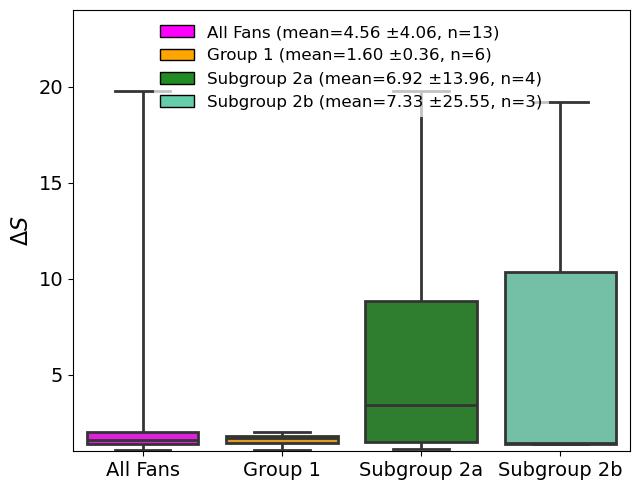

In [110]:
# =============================================
# Gradient Ratio Boxplot by Group (reusing existing definitions)
# =============================================

# ----------------------------------------
# Verify prerequisites
# ----------------------------------------
if "gradient_df" not in globals():
    raise ValueError("❌ gradient_df not found — please compute gradients first.")
if "Group" not in gradient_df.columns and "Group" not in df.columns:
    raise ValueError("❌ No group assignments found — please define df['Group'] first.")

# ----------------------------------------
# Use existing group assignments
# ----------------------------------------
if "Group" not in gradient_df.columns:
    # inherit from df if gradient_df doesn't yet have the group column
    gradient_df = gradient_df.merge(df[["Fan", "Group"]].drop_duplicates(), on="Fan", how="left")

# ----------------------------------------
# Prepare clean data
# ----------------------------------------
plot_df = gradient_df.copy()
plot_df = plot_df.rename(columns={"Gradient Ratio (Drainage/Fan)": "ratio"})

# Filter valid groups
valid_groups = ["Group 1", "Subgroup 2a", "Subgroup 2b"]
plot_df = plot_df[plot_df["Group"].isin(valid_groups)]

# Add combined “All Fans” category
all_fans_df = plot_df[["Fan", "ratio"]].copy()
all_fans_df["Group"] = "All Fans"

# Combine all
plot_data = pd.concat([plot_df, all_fans_df], ignore_index=True)

# ----------------------------------------
# Color palette (same as earlier)
# ----------------------------------------
colors = {
    "Group 1": "orange",
    "Subgroup 2a": "forestgreen",
    "Subgroup 2b": "mediumaquamarine",
    "All Fans": "magenta"
}
category_order = ["All Fans", "Group 1", "Subgroup 2a", "Subgroup 2b"]
palette = [colors.get(c, "lightgray") for c in category_order]

# ----------------------------------------
# Boxplot
# ----------------------------------------
plt.figure(figsize=(6.5, 5))
ax = sns.boxplot(
    x="Group",
    y="ratio",
    data=plot_data,
    palette=palette,
    showfliers=False,
    linewidth=2,
    whis=[0, 100],
    order=category_order
)

# ----------------------------------------
# Legend with mean ± 95% CI
# ----------------------------------------
legend_elements = []
for c in category_order:
    xdata = plot_data.loc[plot_data["Group"] == c, "ratio"].dropna()
    n_val = len(xdata)
    if n_val > 1:
        mean_val = xdata.mean()
        ci_low, ci_high = stats.t.interval(0.95, n_val - 1, loc=mean_val, scale=stats.sem(xdata))
        ci_val = ci_high - mean_val
    elif n_val == 1:
        mean_val, ci_val = xdata.iloc[0], 0
    else:
        mean_val, ci_val = 0, 0

    legend_elements.append(
        Patch(
            facecolor=colors.get(c, "lightgray"),
            edgecolor="k",
            label=f"{c} (mean={mean_val:.2f} ±{ci_val:.2f}, n={n_val})"
        )
    )

# ----------------------------------------
# Final formatting
# ----------------------------------------
ax.set_xlabel("", fontsize=16)
ax.set_ylabel(r"$\Delta S$", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.set_ylim(1, 24)
ax.grid(False)

# Create legend
leg = ax.legend(
    handles=legend_elements,
    fontsize=12,
    loc="upper center",
    frameon=True,
    fancybox=True
)

# Semi-transparent background
frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_alpha(0.7)
frame.set_edgecolor("none")  # ✅ Correct method name

plt.tight_layout()
plt.show()


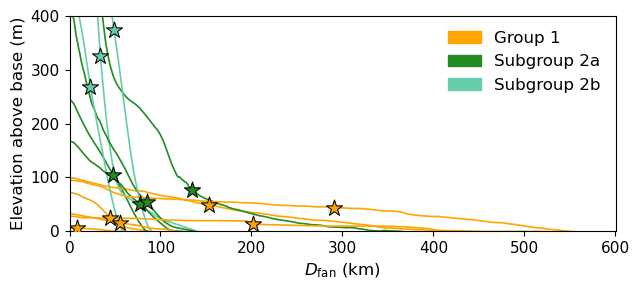

In [36]:
# -----------------------------------------------------
# Plot fan topographic profiles using existing groups
# -----------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(6.5, 3))
ax1 = plt.gca()

window_size_elev = 10  # smoothing window

for fan in df2["Fan"].unique():
    df_fan = df2[df2["Fan"] == fan].copy().sort_values("Distance").reset_index(drop=True)
    
    # Smooth elevations
    df_fan["Confinement_smooth"] = df_fan["Mean Elevation"].rolling(
        window=window_size_elev, min_periods=1, center=True
    ).mean()
    df_fan["River_smooth"] = df_fan["River Elevation"].rolling(
        window=window_size_elev, min_periods=1, center=True
    ).mean()
    
    # Normalize elevation so lowest point = 0
    min_elev = df_fan["Confinement_smooth"].min()
    df_fan["River_norm"] = df_fan["River_smooth"] - min_elev
    
    # Use your pre-existing subgroup definitions
    group = assign_group(fan)
    color = colors.get(group, "gray")
    
    # Plot normalized river elevation
    ax1.plot(
        df_fan["Distance"],
        df_fan["River_norm"],
        color=color,
        linewidth=1.2,
        label=None  # don’t list each fan individually
    )
    
    # Apex markers (colored stars with black outlines)
    apex_idx = df_fan[df_fan["Apex"].isin(["Apex", "Both"])].index
    if len(apex_idx) > 0:
        ax1.scatter(
            df_fan.loc[apex_idx, "Distance"],
            df_fan.loc[apex_idx, "River_norm"],
            facecolor=color,
            edgecolor="black",
            marker="*",
            s=150,
            linewidth=0.75,
            zorder=5
        )

# -----------------------------------------------------
# Axis and panel settings
# -----------------------------------------------------
ax1.set_ylabel("Elevation above base (m)", fontsize=12)
ax1.set_ylim(0, 400)
ax1.set_xlabel(r"$D_{\mathrm{fan}}$ (km)", fontsize=12)
ax1.set_xlim(left=0)
ax1.grid(False)
ax1.tick_params(axis="both", labelsize=11)

# -----------------------------------------------------
# Legend (Subgroups only)
# -----------------------------------------------------
handles = [
    mpatches.Patch(color=colors[g], label=g)
    for g in ["Group 1", "Subgroup 2a", "Subgroup 2b"]
]
leg = ax1.legend(handles=handles, fontsize=12, loc="upper right", frameon=True, fancybox=True)

# Semi-transparent white background so it doesn’t cover profiles
frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_alpha(0.7)
frame.set_edgecolor("none")

plt.tight_layout()
plt.show()


In [19]:
fan_drops = []

for fan in df2["Fan"].unique():
    df_fan = df2[df2["Fan"] == fan].copy().sort_values("Distance")
    
    # Get apex elevation (where Apex == "Apex" or "Both")
    apex_elev = df_fan.loc[df_fan["Apex"].isin(["Apex", "Both"]), "River Elevation"]
    apex_elev = apex_elev.values[0] if not apex_elev.empty else df_fan["River Elevation"].iloc[0]
    
    # Get end elevation (last distance value)
    toe_elev = df_fan["River Elevation"].iloc[-1]
    
    # Compute elevation drop
    elev_drop = apex_elev - toe_elev
    fan_drops.append((fan, round(apex_elev, 2), round(toe_elev, 2), round(elev_drop, 2)))

# Make table
drop_df = pd.DataFrame(fan_drops, columns=["Fan", "Apex Elev (m)", "Toe Elev (m)", "Elevation Drop (m)"])
print(drop_df)


                 Fan  Apex Elev (m)  Toe Elev (m)  Elevation Drop (m)
0           Abrisham         730.70        706.02               24.67
1            Canning         110.22          1.05              109.17
2              Cusay         457.36        139.39              317.97
3                Ili         391.00        341.20               49.80
4            Karnali         188.50        133.00               55.50
5               Kosi         106.91         24.00               82.91
6              Manas         103.03         34.70               68.33
7              Niger         274.00        258.04               15.96
8          Nomhon He        3069.78       2698.85              370.93
9           Okavango         975.00        929.59               45.41
10  Rud-i-Shur Tabas         862.34        593.16              269.19
11      Saskatchewan         274.00        265.50                8.50
12             Shire          63.50         44.27               19.23


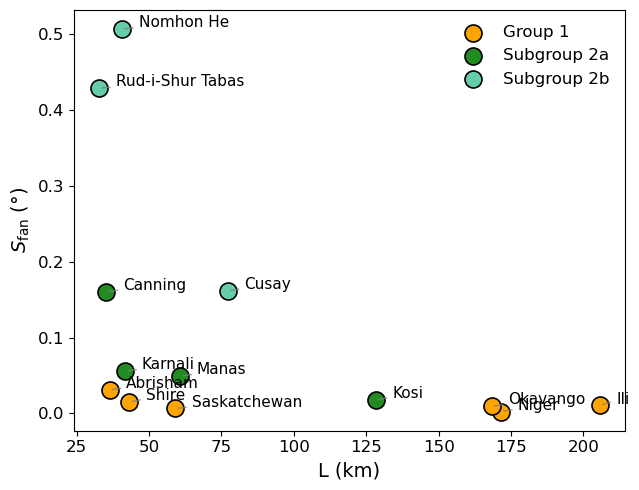

In [37]:
# -----------------------------------------------------
# Fan Length vs Gradient (using updated subgroups)
# -----------------------------------------------------

# --- Verify prerequisites ---
if not all(x in globals() for x in ["apex_coords", "toe_coords", "gradient_df", "assign_group", "colors"]):
    raise ValueError("❌ Missing one of the required variables: apex_coords, toe_coords, gradient_df, assign_group, colors")

# --- Haversine (great-circle distance) ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# --- Build DataFrame of lengths and gradients ---
fan_records = []
for fan in apex_coords.keys():
    if fan not in toe_coords:
        print(f"⚠️ Skipping {fan} — missing toe coordinates.")
        continue

    lat1, lon1 = apex_coords[fan]
    lat2, lon2 = toe_coords[fan]
    length_km = haversine(lat1, lon1, lat2, lon2) / 1000  # convert to km

    grad_val = np.nan
    if "Fan Gradient (°)" in gradient_df.columns:
        row = gradient_df.loc[gradient_df["Fan"] == fan]
        if not row.empty:
            grad_val = row["Fan Gradient (°)"].iloc[0]

    fan_records.append({
        "Fan": fan,
        "Group": assign_group(fan),  # ✅ will assign Group 1 / Subgroup 2a / Subgroup 2b
        "Fan Length (km)": length_km,
        "Fan Gradient (°)": grad_val
    })

plot_df = pd.DataFrame(fan_records).dropna(subset=["Fan Gradient (°)"])

# --- Labeling helper ---
def smart_label(ax, x, y, fan, offsets=None, color="black"):
    ax.figure.canvas.draw()
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    dx_base = 0.03 * (xlim[1] - xlim[0])
    dy_base = 0.015 * (ylim[1] - ylim[0])
    if offsets:
        dx_scaled = offsets.get("dx", 0.03) * (xlim[1] - xlim[0])
        dy_scaled = offsets.get("dy", 0.015) * (ylim[1] - ylim[0])
    else:
        dx_scaled, dy_scaled = dx_base, dy_base
    ax.annotate(
        fan,
        xy=(x, y),
        xytext=(x + dx_scaled, y + dy_scaled),
        fontsize=11,
        ha="left",
        va="center",
        color=color,
        arrowprops=dict(arrowstyle="-", lw=1.0, color="gray", alpha=0.8)
    )

# --- Plot ---
fig, ax = plt.subplots(figsize=(6.5, 5))

# ✅ Updated color dictionary for consistency
colors = {
    "Group 1": "#FFA500",        # orange
    "Subgroup 2a": "#228B22",    # forest green
    "Subgroup 2b": "#66CDAA"     # medium aquamarine
}

for group, color in colors.items():
    subset = plot_df[plot_df["Group"] == group]
    if subset.empty:
        continue
    sns.scatterplot(
        data=subset,
        x="Fan Length (km)",
        y="Fan Gradient (°)",
        s=150,
        color=color,
        edgecolor="black",
        linewidth=1.2,
        label=group,
        ax=ax
    )

# --- Labels ---
for _, row in plot_df.iterrows():
    smart_label(ax, row["Fan Length (km)"], row["Fan Gradient (°)"], row["Fan"])

# --- Formatting ---
ax.set_xlabel("L (km)", fontsize=14)
ax.set_ylabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12, frameon=False, loc="upper right")
ax.grid(False)
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()


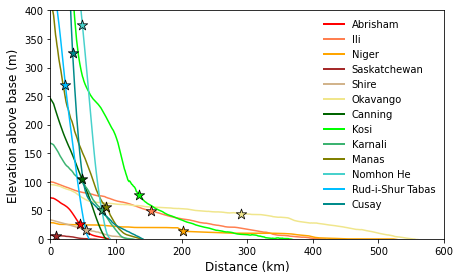

In [37]:
# -----------------------------------------------------
# Plot fan topographic profiles (individual fan colors)
# -----------------------------------------------------

plt.figure(figsize=(6.5, 4))
ax1 = plt.gca()

window_size_elev = 10  # smoothing window

# Manually define fan colors (in desired legend order)
fan_colors = {
    # Group 1
    "Abrisham": "red",
    "Ili": "coral", 
    "Niger": "orange",
    "Saskatchewan": "brown",
    "Shire": "tan",
    "Okavango": "khaki",
    # Group 2a
    "Canning": "darkgreen",
    "Kosi": "lime",
    "Karnali": "mediumseagreen",
    "Manas": "olive",
    # Group 2b
    "Nomhon He": "mediumturquoise",
    "Rud-i-Shur Tabas": "deepskyblue",
    "Cusay": "darkcyan"
}

# -----------------------------------------------------
# Plot each fan’s profile
# -----------------------------------------------------
for fan in fan_colors.keys():  # ensure order matches dictionary
    if fan not in df2['Fan'].unique():
        continue
    df_fan = df2[df2['Fan'] == fan].copy().sort_values('Distance').reset_index(drop=True)
    
    # Smooth elevations
    df_fan['Confinement_smooth'] = df_fan['Mean Elevation'].rolling(
        window=window_size_elev, min_periods=1, center=True).mean()
    df_fan['River_smooth'] = df_fan['River Elevation'].rolling(
        window=window_size_elev, min_periods=1, center=True).mean()
    
    # Normalize elevation so lowest point = 0
    min_elev = df_fan['Confinement_smooth'].min()
    df_fan['River_norm'] = df_fan['River_smooth'] - min_elev
    
    color = fan_colors[fan]
    
    # Plot line
    ax1.plot(df_fan['Distance'], df_fan['River_norm'],
             color=color, linewidth=1.5, label=fan)
    
    # Apex markers (colored star with black outline)
    apex_idx = df_fan[df_fan['Apex'].isin(['Apex', 'Both'])].index
    if len(apex_idx) > 0:
        ax1.scatter(df_fan.loc[apex_idx, 'Distance'],
                    df_fan.loc[apex_idx, 'River_norm'],
                    facecolor=color, edgecolor='black',
                    marker='*', s=120, linewidth=0.75, zorder=5)

# -----------------------------------------------------
# Axis and panel settings
# -----------------------------------------------------
ax1.set_ylabel('Elevation above base (m)', fontsize=12)
ax1.set_ylim(0, 400)
ax1.set_xlabel('Distance (km)', fontsize=12)
ax1.set_xlim(left=0)
ax1.grid(False)

# -----------------------------------------------------
# Legend (preserving manual color order)
# -----------------------------------------------------
handles = [plt.Line2D([0], [0], color=fan_colors[fan], lw=2, label=fan)
           for fan in fan_colors.keys()]
ax1.legend(handles=handles, fontsize=10, loc='upper right', frameon=False, ncol=1)

plt.tight_layout()
plt.show()


In [93]:
# ==========================================================
# Merge gradient data (handles duplicates + flexible naming)
# ==========================================================
grad_cols = list(gradient_df.columns)
grad_map = {}

for col in grad_cols:
    name_lower = col.lower()
    if "drainage" in name_lower:
        grad_map["Drainage Gradient (°)"] = col
    elif "fan gradient" in name_lower:
        grad_map["Fan Gradient (°)"] = col
    elif "ratio" in name_lower or "apex" in name_lower:
        grad_map["Gradient Ratio (Drainage/Fan)"] = col

# 🧹 Drop existing gradient columns in df before merge to prevent conflicts
for col in ["Drainage Gradient (°)", "Fan Gradient (°)", "Gradient Ratio (Drainage/Fan)"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# ✅ Safe merge now (no duplicate name conflicts)
df = df.merge(
    gradient_df[["Fan"] + list(grad_map.values())],
    on="Fan", how="left"
).rename(columns={v: k for k, v in grad_map.items()})

print(f"✅ Merged gradient data for {df['Fan'].nunique()} fans")

# ==========================================================
# STEP 5 — Add gradient ranges (drainage, fan, and apex change)
# ==========================================================

# --- Define subgroups ---
group_1_fans = ["Niger", "Okavango", "Saskatchewan", "Shire", "Abrisham", "Ili"]
subgroup_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
subgroup_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

def assign_subgroup(fan_name):
    if fan_name in group_1_fans:
        return "Group 1"
    elif fan_name in subgroup_2a_fans:
        return "Subgroup 2a"
    elif fan_name in subgroup_2b_fans:
        return "Subgroup 2b"
    else:
        return "Other"

df["Group"] = df["Fan"].apply(assign_subgroup)

# ==========================================================
# (continue with bootstrap_ci, sigfig, and summary code)
# ==========================================================


✅ Merged gradient data for 13 fans


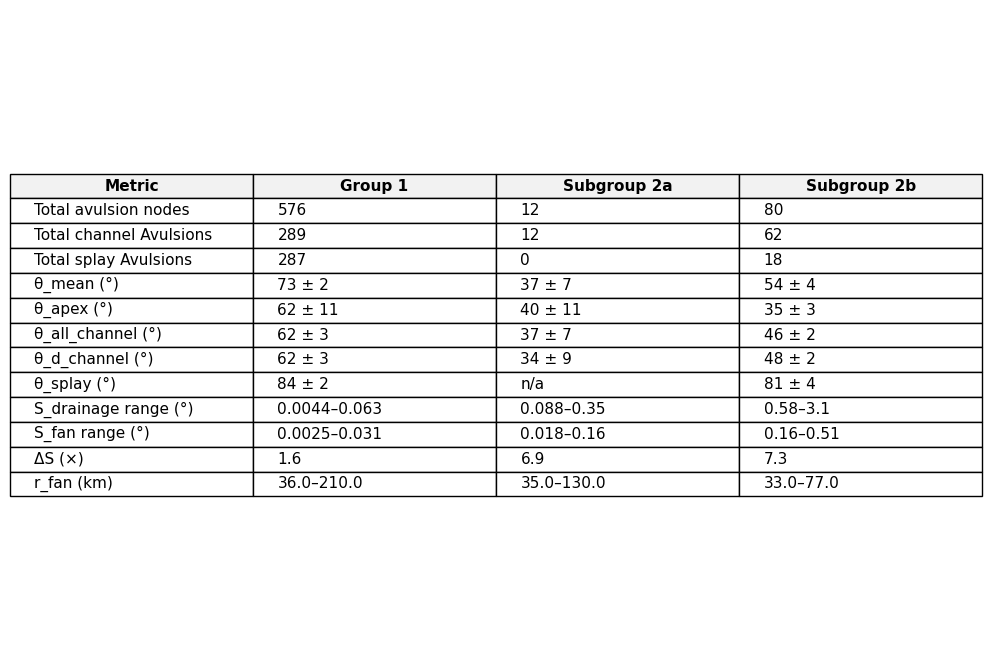

In [55]:
# ==========================================================
# FINAL CLEAN VERSION – Gradient + Length Summary Table
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Define fan subgroups
# -----------------------------
group_1_fans   = ["Niger", "Okavango", "Saskatchewan", "Shire", "Abrisham", "Ili"]
subgroup_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
subgroup_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

def assign_subgroup(fan_name):
    if fan_name in group_1_fans:
        return "Group 1"
    elif fan_name in subgroup_2a_fans:
        return "Subgroup 2a"
    elif fan_name in subgroup_2b_fans:
        return "Subgroup 2b"
    else:
        return "Other"

# Add grouping if missing
if "Group" not in df.columns:
    df["Group"] = df["Fan"].apply(assign_subgroup)

# ==========================================================
# Attach gradient data (clean merge)
# ==========================================================
grad_df = gradient_df.copy()
grad_df["Group"] = grad_df["Fan"].apply(assign_subgroup)

for col in ["Drainage Gradient (°)", "Fan Gradient (°)", "Gradient Ratio (Drainage/Fan)"]:
    grad_df[col] = pd.to_numeric(grad_df[col], errors="coerce")

# ==========================================================
# Compute fan lengths (r_fan) using apex and toe coordinates
# ==========================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

fan_lengths = []
for fan in apex_coords.keys():
    if fan not in toe_coords:
        print(f"⚠️ Skipping {fan} — missing toe coordinates.")
        continue
    lat1, lon1 = apex_coords[fan]
    lat2, lon2 = toe_coords[fan]
    length_km = haversine(lat1, lon1, lat2, lon2) / 1000
    fan_lengths.append({"Fan": fan, "r_fan (km)": length_km})

fan_length_df = pd.DataFrame(fan_lengths)
fan_length_df["Group"] = fan_length_df["Fan"].apply(assign_subgroup)

# ==========================================================
# Bootstrap mean ± 95% CI
# ==========================================================
def bootstrap_ci(series, n_boot=1000, ci=95, random_state=42):
    x = pd.to_numeric(series, errors="coerce").dropna().values
    if len(x) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(random_state)
    means = [np.mean(rng.choice(x, len(x), replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    mean_val = np.mean(x)
    ci_half = hi - mean_val
    return mean_val, ci_half

def sigfig(x, sig=2):
    if pd.isna(x):
        return np.nan
    try:
        return float(f"{float(x):.{sig}g}")
    except Exception:
        return np.nan

# ==========================================================
# Compute per-group summaries
# ==========================================================
summary = []
wanted_groups = ["Group 1", "Subgroup 2a", "Subgroup 2b"]

for group in wanted_groups:
    sub = df[df["Group"] == group]
    grad_sub = grad_df[grad_df["Group"] == group]
    len_sub  = fan_length_df[fan_length_df["Group"] == group]

    total_nodes = len(sub)
    channel_nodes = (sub["Crevasse"] == "No").sum()
    splay_nodes = (sub["Crevasse"] == "Yes").sum()

    mean_angle, ci_angle = bootstrap_ci(sub["Angle"])
    mean_apex, ci_apex = bootstrap_ci(sub.loc[sub["Apex"] == "Yes", "Angle"])
    mean_all_channel, ci_all_channel = bootstrap_ci(sub.loc[sub["Crevasse"] == "No", "Angle"])
    mean_downfan, ci_downfan = bootstrap_ci(sub.loc[(sub["Apex"] == "No") & (sub["Crevasse"] == "No"), "Angle"])
    mean_splay, ci_splay = bootstrap_ci(sub.loc[sub["Crevasse"] == "Yes", "Angle"])

    # Gradient ranges
    dmin, dmax = grad_sub["Drainage Gradient (°)"].min(), grad_sub["Drainage Gradient (°)"].max()
    fmin, fmax = grad_sub["Fan Gradient (°)"].min(), grad_sub["Fan Gradient (°)"].max()
    ratio_mean = grad_sub["Gradient Ratio (Drainage/Fan)"].mean()

    # Fan length range (r_fan)
    lmin, lmax = len_sub["r_fan (km)"].min(), len_sub["r_fan (km)"].max()

    # Format displays
    drain_display = f"{sigfig(dmin)}–{sigfig(dmax)}"
    fan_display   = f"{sigfig(fmin)}–{sigfig(fmax)}"
    ratio_display = f"{sigfig(ratio_mean)}" if not np.isnan(ratio_mean) else "n/a"
    length_display = f"{sigfig(lmin)}–{sigfig(lmax)}" if not np.isnan(lmin) else "n/a"

    summary.append({
        "Group": group,
        "Total avulsion nodes": total_nodes,
        "Total channel Avulsions": channel_nodes,
        "Total splay Avulsions": splay_nodes,
        "θ_mean (°)": f"{int(round(mean_angle))} ± {int(round(ci_angle))}" if not np.isnan(mean_angle) else "n/a",
        "θ_apex (°)": f"{int(round(mean_apex))} ± {int(round(ci_apex))}" if not np.isnan(mean_apex) else "n/a",
        "θ_all_channel (°)": f"{int(round(mean_all_channel))} ± {int(round(ci_all_channel))}" if not np.isnan(mean_all_channel) else "n/a",
        "θ_d_channel (°)": f"{int(round(mean_downfan))} ± {int(round(ci_downfan))}" if not np.isnan(mean_downfan) else "n/a",
        "θ_splay (°)": f"{int(round(mean_splay))} ± {int(round(ci_splay))}" if not np.isnan(mean_splay) else "n/a",
        "S_drainage range (°)": drain_display,
        "S_fan range (°)": fan_display,
        "ΔS (×)": ratio_display,
        "r_fan (km)": length_display  # NEW
    })

summary_df = pd.DataFrame(summary)

# ==========================================================
# Pivot for display
# ==========================================================
table = summary_df.set_index("Group").T.reset_index().rename(columns={"index": "Metric"})
table = table.reindex(columns=["Metric"] + wanted_groups)

# ==========================================================
# Plot table
# ==========================================================
fig_h = 0.45 * len(table) + 1.4
fig, ax = plt.subplots(figsize=(10.5, fig_h))
ax.axis("off")

tbl = ax.table(
    cellText=table.values.tolist(),
    colLabels=table.columns.tolist(),
    colLoc="center",
    cellLoc="left",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.2)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold", va="center")
        cell.set_facecolor("#f2f2f2")

plt.tight_layout()
plt.show()


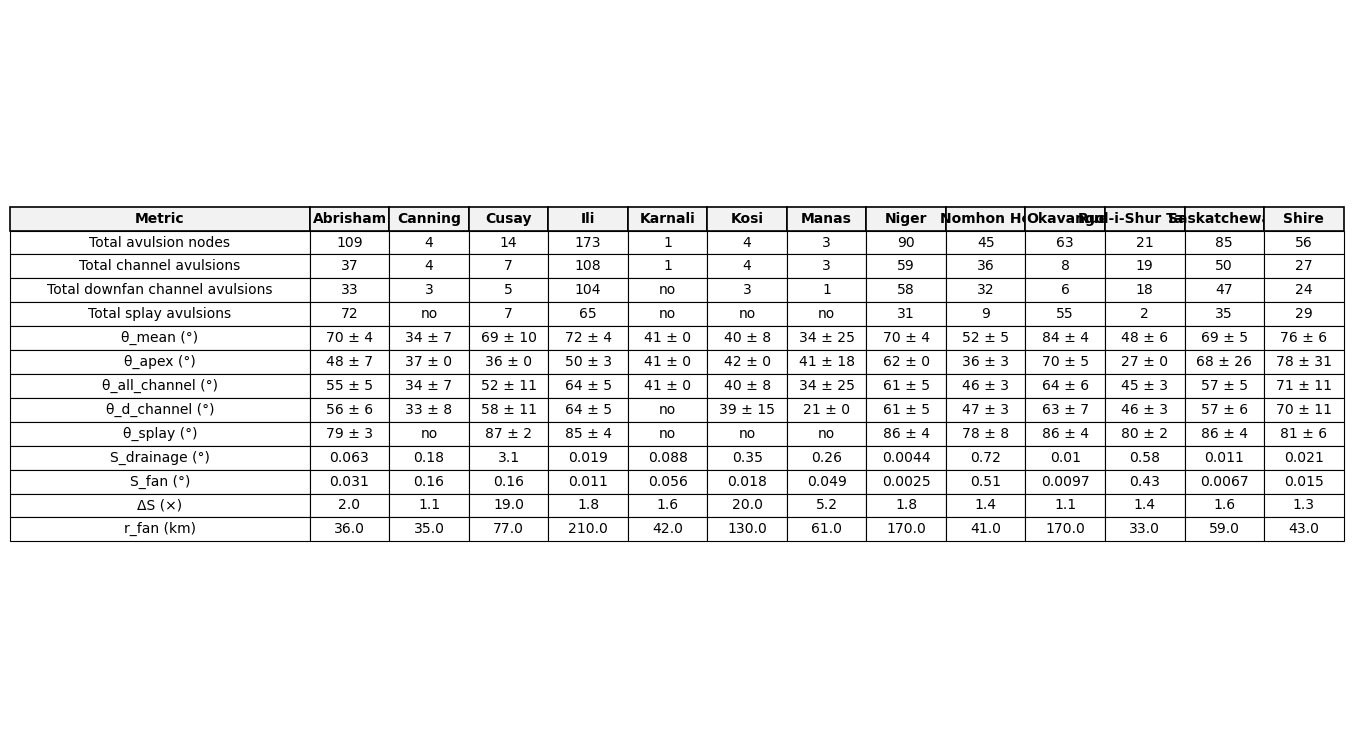

In [61]:
# ==========================================================
# FINAL POLISHED VERSION – Per-Fan Gradient + Length Summary Table
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Compute fan lengths (r_fan) using apex and toe coordinates
# ==========================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

fan_lengths = []
for fan in apex_coords.keys():
    if fan not in toe_coords:
        print(f"⚠️ Skipping {fan} — missing toe coordinates.")
        continue
    lat1, lon1 = apex_coords[fan]
    lat2, lon2 = toe_coords[fan]
    length_km = haversine(lat1, lon1, lat2, lon2) / 1000
    fan_lengths.append({"Fan": fan, "r_fan (km)": length_km})
fan_length_df = pd.DataFrame(fan_lengths)

# ==========================================================
# Clean gradient dataframe
# ==========================================================
grad_df = gradient_df.copy()
for col in ["Drainage Gradient (°)", "Fan Gradient (°)", "Gradient Ratio (Drainage/Fan)"]:
    grad_df[col] = pd.to_numeric(grad_df[col], errors="coerce")

# ==========================================================
# Bootstrap mean ± 95% CI
# ==========================================================
def bootstrap_ci(series, n_boot=1000, ci=95, random_state=42):
    x = pd.to_numeric(series, errors="coerce").dropna().values
    if len(x) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(random_state)
    means = [np.mean(rng.choice(x, len(x), replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    mean_val = np.mean(x)
    ci_half = hi - mean_val
    return mean_val, ci_half

def sigfig(x, sig=2):
    if pd.isna(x):
        return np.nan
    try:
        return float(f"{float(x):.{sig}g}")
    except Exception:
        return np.nan

# ==========================================================
# Compute per-fan summaries
# ==========================================================
summary = []
all_fans = sorted(df["Fan"].unique())

for fan in all_fans:
    sub = df[df["Fan"] == fan]
    grad_sub = grad_df[grad_df["Fan"] == fan]
    len_sub = fan_length_df[fan_length_df["Fan"] == fan]

    total_nodes = len(sub)
    channel_nodes = (sub["Crevasse"] == "No").sum()
    downfan_channel_nodes = ((sub["Apex"] == "No") & (sub["Crevasse"] == "No")).sum()
    splay_nodes = (sub["Crevasse"] == "Yes").sum()

    mean_angle, ci_angle = bootstrap_ci(sub["Angle"])
    mean_apex, ci_apex = bootstrap_ci(sub.loc[sub["Apex"] == "Yes", "Angle"])
    mean_all_channel, ci_all_channel = bootstrap_ci(sub.loc[sub["Crevasse"] == "No", "Angle"])
    mean_downfan, ci_downfan = bootstrap_ci(sub.loc[(sub["Apex"] == "No") & (sub["Crevasse"] == "No"), "Angle"])
    mean_splay, ci_splay = bootstrap_ci(sub.loc[sub["Crevasse"] == "Yes", "Angle"])

    dgrad = grad_sub["Drainage Gradient (°)"].iloc[0] if not grad_sub.empty else np.nan
    fgrad = grad_sub["Fan Gradient (°)"].iloc[0] if not grad_sub.empty else np.nan
    ratio = grad_sub["Gradient Ratio (Drainage/Fan)"].iloc[0] if not grad_sub.empty else np.nan
    rfan = len_sub["r_fan (km)"].iloc[0] if not len_sub.empty else np.nan

    def fmt(val, ci=None):
        if pd.isna(val):
            return "no"
        if ci is None or pd.isna(ci):
            return f"{int(round(val))}"
        return f"{int(round(val))} ± {int(round(ci))}"

    def fmtnum(val):
        return f"{sigfig(val)}" if not pd.isna(val) else "no"

    summary.append({
        "Fan": fan,
        "Total avulsion nodes": total_nodes if total_nodes > 0 else "no",
        "Total channel avulsions": channel_nodes if channel_nodes > 0 else "no",
        "Total downfan channel avulsions": downfan_channel_nodes if downfan_channel_nodes > 0 else "no",
        "Total splay avulsions": splay_nodes if splay_nodes > 0 else "no",
        "θ_mean (°)": fmt(mean_angle, ci_angle),
        "θ_apex (°)": fmt(mean_apex, ci_apex),
        "θ_all_channel (°)": fmt(mean_all_channel, ci_all_channel),
        "θ_d_channel (°)": fmt(mean_downfan, ci_downfan),
        "θ_splay (°)": fmt(mean_splay, ci_splay),
        "S_drainage (°)": fmtnum(dgrad),
        "S_fan (°)": fmtnum(fgrad),
        "ΔS (×)": fmtnum(ratio),
        "r_fan (km)": fmtnum(rfan)
    })

summary_df = pd.DataFrame(summary)

# ==========================================================
# Pivot for display (each fan = column)
# ==========================================================
table = summary_df.set_index("Fan").T.reset_index().rename(columns={"index": "Metric"})

# ==========================================================
# Plot table (centered text, wider left column, framed)
# ==========================================================
fig_h = 0.46 * len(table) + 1.6
fig_w = 1.2 * len(all_fans)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")

tbl = ax.table(
    cellText=table.values.tolist(),
    colLabels=table.columns.tolist(),
    cellLoc="center",    # Center text horizontally
    colLoc="center",     # Center headers
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.15)

# Make first column (metrics) a bit wider
for (r, c), cell in tbl.get_celld().items():
    # Header
    if r == 0:
        cell.set_text_props(weight="bold", va="center", ha="center")
        cell.set_facecolor("#f2f2f2")
        cell.set_linewidth(1.2)
    else:
        cell.set_text_props(va="center", ha="center")
        cell.set_linewidth(0.8)
    # Widen first (Metric) column
    if c == 0:
        cell.set_width(0.35)

plt.tight_layout()
plt.show()



In [68]:
# ==========================================================
# Save summary table as CSV in Jupyter home directory
# ==========================================================
import os

# Save to your Jupyter start folder (usually where you launch the notebook)
save_path = os.path.join(os.getcwd(), "Fan_Gradient_Length_Summary.csv")

# Save the table (same layout as your plotted one)
table.to_csv(save_path, index=False)
print(f"✅ Saved CSV to:\n{save_path}")


✅ Saved CSV to:
C:\Users\lukej\Fan_Gradient_Length_Summary.csv
